# NFL Prospect Bin Scoring — v1 (Proportion Scoring)

**Goal:** For each player, measure what proportion of their scouting language falls into three bins:
1. **Physical** — size, speed, athleticism, body traits
2. **Technique/Skills** — football-specific craft, stamina, energy
3. **Character/IQ** — effort, intelligence, decision-making, intangibles

**Method:** Keyword proportion scoring. After preprocessing, count how many tokens match each bin's keyword set, then divide by total matched tokens → three proportions that sum to 100%.

**Pipeline:**
1. Phrase stitching (curated, NFL-aware)
2. Stopword removal (custom, NFL-aware)
3. Lemmatization
4. Dictionary seeding (manual anchor keywords per bin)
5. Word2Vec expansion (grow keyword lists using corpus semantics)
6. Proportion scoring (keyword token counting)
7. Output: proportions + top matched keywords per player

In [147]:
import pandas as pd
import numpy as np
import re
import json
from collections import Counter
from itertools import combinations

import nltk
from nltk.stem import WordNetLemmatizer
from gensim.models import Word2Vec

nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)

# ── Config ─────────────────────────────────────────────────────────────────────
W2V_DIM       = 100   # embedding dimensions
W2V_WINDOW    = 6     # context window
W2V_EPOCHS    = 30    # training passes
W2V_SG        = 1     # 1 = skip-gram
W2V_MIN_COUNT = 3     # ignore tokens appearing fewer than N times

SEED_TOPN      = 20   # W2V neighbors to retrieve per seed
SIM_THRESHOLD  = 0.38 # min cosine similarity for expansion candidates
MIN_SEED_COUNT = 1    # candidate must appear near >= N seeds (1 = widest coverage)
MAX_W2V_TERMS  = 60   # max W2V-expanded terms added per bin

TOP_TERMS_N = 5       # top matched keywords to surface per player-bin pair

BIN_NAMES = ['physical', 'technique', 'character']

FILTER_SPECIALISTS = True   # set False to include K, P, LS in all analysis

print('Imports OK')

Imports OK


## Section 1 — Load Data

In [148]:
df = pd.read_csv('../data/processed/draft_enriched_with_contracts.csv')

keep_cols = ['player_name', 'Pos_Group', 'position', 'grade', 'year',
             'made_it_contract', 'overview', 'strengths', 'weaknesses']
df = df[keep_cols].copy()

# Fill missing text — keep all rows, never drop
for col in ['overview', 'strengths', 'weaknesses']:
    df[col] = df[col].fillna('')

print(f'Players: {len(df)}')
print(f'Positions: {df["position"].nunique()} unique')
print(f'\nText coverage:')
for col in ['overview', 'strengths', 'weaknesses']:
    pct = (df[col].str.strip() != '').mean() * 100
    print(f'  {col:12s}: {pct:.1f}%')
# ── Specialist filter ───────────────────────────────────────────────────────────
if FILTER_SPECIALISTS:
    n_before = len(df)
    df = df[df['Pos_Group'] != 'SPECIAL'].reset_index(drop=True)
    print(f'Specialists removed: {n_before - len(df)}  (K, P, LS — Pos_Group=SPECIAL)')
    print(f'Players remaining  : {len(df)}')
else:
    print('Specialists included.')

Players: 7396
Positions: 31 unique

Text coverage:
  overview    : 90.3%
  strengths   : 90.3%
  weaknesses  : 90.3%
Specialists removed: 223  (K, P, LS — Pos_Group=SPECIAL)
Players remaining  : 7173


## Section 2 — Preprocessing

Three steps applied in order:
1. **Phrase stitching** — replace multi-word NFL terms with underscore tokens *before* any tokenization, so `route running` → `route_running` survives as a single unit
2. **Stopword removal** — custom NFL-aware list; preserves football-relevant words like `high`, `low`, `hard`, `soft` that standard NLTK stops would remove
3. **Lemmatization** — reduces inflected forms to base (`rushing` → `rush`, `blocks` → `block`)

*PMI bigram discovery removed from v3 — curated phrases only, for simplicity and reproducibility.*

In [ ]:
# ── Curated compound NFL terms ─────────────────────────────────────────────────
# Sorted longest-first to prevent partial matches (trigrams before bigrams).
_CURATED_RAW = {
    # ── Trigrams (seed-critical) ───────────────────────────────────────────────
    'change of direction':      'change_of_direction',
    'stack and shed':           'stack_and_shed',
    'run after catch':          'run_after_catch',
    'yards after contact':      'yards_after_contact',
    'point of attack':          'point_of_attack',
    'block shedding':           'block_shedding',
    'anchor strength':          'anchor_strength',
    'sideline to sideline':     'sideline_to_sideline',

    # ── Seed-critical bigrams ──────────────────────────────────────────────────
    'pass protection':          'pass_protection',
    'pass coverage':            'pass_coverage',
    'pass rusher':              'pass_rusher',
    'pass rush':                'pass_rush',
    'press coverage':           'press_coverage',
    'man coverage':             'man_coverage',
    'man to man':               'man_coverage',
    'zone coverage':            'zone_coverage',
    'zone coverages':           'zone_coverages',
    'hand fighting':            'hand_fighting',
    'route running':            'route_running',
    'pad level':                'pad_level',
    'high motor':               'high_motor',
    'football iq':              'football_iq',
    'work ethic':               'work_ethic',
    'first step':               'first_step',
    'get off':                  'get_off',

    # ── High-value extras — Physical ──────────────────────────────────────────
    'body control':             'body_control',
    'lateral quickness':        'lateral_quickness',
    'quick twitch':             'quick_twitch',
    'arm strength':             'arm_strength',
    'closing speed':            'closing_speed',
    'change of pace':           'change_of_pace',
    'short area':               'short_area',
    'top end':                  'top_end',
    'edge-to-edge':             'edge_to_edge',
    'play strength':            'play_strength',
    'foot quickness':           'foot_quickness',
    'through contact':          'through_contact',
    'recovery speed':           'recovery_speed',
    'closing burst':            'closing_burst',
    'core strength':            'core_strength',
    'pursuit speed':            'pursuit_speed',
    'arm talent':               'arm_talent',
    'long arms':                'long_arm',
    'long arm':                 'long_arm',
    'size speed':               'size_speed',
    'initial quickness':        'initial_quickness',

    # ── High-value extras — Technique ─────────────────────────────────────────
    'run blocking':             'run_blocking',
    'ball skills':              'ball_skills',
    'contact balance':          'contact_balance',
    'hand placement':           'hand_placement',
    'hand strength':            'hand_strength',
    'soft hands':               'soft_hands',
    'heavy hands':              'heavy_hands',
    'strong hands':             'strong_hands',
    'active hands':             'active_hands',
    'high point':               'high_point',
    'bull rush':                'bull_rush',
    'bull rusher':              'bull_rusher',
    'spin move':                'spin_move',
    'swim move':                'swim_move',
    'speed rush':               'speed_rush',
    'run support':              'run_support',
    'press technique':          'press_technique',
    'contested catch':          'contested_catch',
    'run defense':              'run_defense',
    'pursuit angle':            'pursuit_angle',
    'punch-and-pull':           'punch_and_pull',
    'leg-drive':                'leg_drive',
    'leg drive':                'leg_drive',
    'catch point':              'catch_point',
    'out breaking':             'out_break',
    'out break':                'out_break',
    'route runner':             'route_runner',
    'route tree':               'route_tree',
    'ball tracking':            'ball_tracking',
    'break tackle':             'break_tackle',
    'ball security':            'ball_security',
    'one cut':                  'one_cut',
    'jump cut':                 'jump_cut',
    'fall forward':             'fall_forward',
    'double team':              'double_team',
    'drive blocker':            'drive_blocker',
    'missed tackle':            'missed_tackle',
    'deep ball':                'deep_ball',
    'pocket passer':            'pocket_passer',
    'pocket mobility':          'pocket_mobility',
    'second level':             'second_level',

    # ── High-value extras — Character / IQ ────────────────────────────────────
    'football intelligence':    'football_intelligence',
    'play recognition':         'play_recognition',
    'decision making':          'decision_making',
    'field vision':             'field_vision',
    'film study':               'film_study',
    'film room':                'film_room',
    'locker room':              'locker_room',
    'mental toughness':         'mental_toughness',
    'blitz awareness':          'blitz_awareness',
    'pocket awareness':         'pocket_awareness',
    'high effort':              'high_effort',
    'hard worker':              'hard_worker',
}

CURATED_PHRASE_MAP = dict(
    sorted(_CURATED_RAW.items(), key=lambda x: len(x[0]), reverse=True)
)
print(f'Curated phrases: {len(CURATED_PHRASE_MAP)}')

# ── NFL-aware stop words ────────────────────────────────────────────────────────
# KEEP_WORDS: pulled out of NLTK's English stoplist so they survive preprocessing.
# Only keep words that carry genuine scouting signal as standalone tokens.
KEEP_WORDS = {
    'high', 'low', 'heavy', 'light', 'deep', 'short', 'long', 'wide',
    'hard', 'soft', 'strong', 'quick', 'great',
    'up', 'down', 'off', 'out', 'over', 'through', 'above', 'below',
    'hand', 'hands', 'back', 'field',
    # NOTE: 'good', 'ball', 'man' removed — too generic; compound phrases
    # (ball_skills, man_coverage) are handled by CURATED_PHRASE_MAP before filtering.
}

CUSTOM_STOPS = {
    'prospect', 'player', 'players', 'show', 'shows', 'need', 'needs',
    'also', 'often', 'must', 'well', 'still', 'use', 'get',
    'make', 'look', 'help', 'time', 'year', 'team', 'game',
    'continue', 'develop', 'development', 'nfl', 'draft', 'college',
    'type', 'project', 'potential', 'upside',
    'starter', 'backup', 'senior', 'junior', 'cb', 'rb', 'wr', 'qb',
    # Generic evaluation language — high-frequency but carry no pillar signal:
    'play', 'run', 'average', 'lack', 'ability', 'position',
    'good', 'ball', 'man', 'line',
}

_base = set(stopwords.words('english'))
NFL_STOPWORDS = (_base - KEEP_WORDS) | CUSTOM_STOPS

print(f'Base NLTK stops  : {len(_base)}')
print(f'Un-stopped        : {len(KEEP_WORDS & _base)}  (kept from NLTK list)')
print(f'Custom added      : {len(CUSTOM_STOPS)}')
print(f'Final stop list   : {len(NFL_STOPWORDS)}')

In [150]:
lemmatizer = WordNetLemmatizer()

def nfl_preprocess(text: str, phrase_map: dict = CURATED_PHRASE_MAP) -> str:
    """NFL-aware preprocessing: normalize → stitch → clean → filter → lemmatize."""
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()
    text = re.sub(r'[-\u2013\u2014]', ' ', text)       # normalize all dash variants
    for phrase, token in phrase_map.items():              # curated phrase stitching
        text = text.replace(phrase, token)
    text = re.sub(r'[^a-z_\s]', ' ', text)              # keep letters + underscores only
    tokens = text.split()
    tokens = [t for t in tokens if '_' in t or t not in NFL_STOPWORDS]
    tokens = [t if '_' in t else lemmatizer.lemmatize(t) for t in tokens]
    tokens = [t for t in tokens if len(t) > 1]
    return ' '.join(tokens)

# Apply to each section
df['strengths_clean']  = df['strengths'].apply(nfl_preprocess)
df['overview_clean']   = df['overview'].apply(nfl_preprocess)
df['weaknesses_clean'] = df['weaknesses'].apply(nfl_preprocess)

# Combine all sections into one token list per player
df['all_text']   = (df['overview_clean'] + ' ' +
                    df['strengths_clean'] + ' ' +
                    df['weaknesses_clean']).str.strip()
df['all_tokens'] = df['all_text'].apply(str.split)

# Section-specific token lists (used for per-section scoring in Section 5)
df['strengths_tokens']  = df['strengths_clean'].apply(str.split)
df['weaknesses_tokens'] = df['weaknesses_clean'].apply(str.split)

lengths = df['all_tokens'].apply(len)
print(f'Preprocessing complete.')
print(f'Tokens per player — median: {lengths.median():.0f},  min: {lengths.min()},  max: {lengths.max()}')

Preprocessing complete.
Tokens per player — median: 116,  min: 0,  max: 381


## Section 3 — Anchor Seeds

Small, unambiguous, high-frequency keyword lists per bin — hand-curated to be clearly
representative of each bin with minimal cross-bin overlap.

These serve two purposes:
1. **Baseline** — guaranteed in the final keyword set regardless of what W2V finds
2. **W2V seeds** — anchor points for vocabulary expansion in the next section

Keep these lists tight. Obvious extensions (`quickness`, `hustle`, `footwork`) are
intentionally left out and recovered by W2V.

In [ ]:
# ── Anchor seeds — minimal, unambiguous, high-frequency ────────────────────────
# Keep this list short and unambiguous. W2V expansion (with MIN_SEED_COUNT=1)
# will surface semantically related terms. Only add words here that are:
#   (a) clearly domain-critical AND
#   (b) either not in W2V vocab, or too far from existing seeds to be expanded,
#       as evidenced by appearing in cell 32's top uncovered tokens or the
#       LDA Section 9 position-level unigram/bigram analysis.
ANCHOR_SEEDS = {
    'physical': [
        'explosive', 'burst', 'speed', 'acceleration', 'first_step', 'get_off',
        'change_of_direction', 'agility', 'frame', 'size', 'strength',
        'power', 'athletic', 'physical', 'twitch',
        'foot',                 # 706 uncovered; covers "feet" after lemmatization
        'hip',                  # 821 uncovered; hips, hip mobility, hip flexibility
        'weight',               # body mass / build descriptors
        'arm',                  # arm length / "thin in the arms"; covers "arms"
        'edge_to_edge',         # hyphen-normalized out of W2V vocab
        'contact',              # RB: 477; physical toughness, through contact
        'downhill',             # LB: 312; aggressive downhill attack style
        # ── new compound seeds (from LDA bigram analysis) ────────────────────
        'play_strength',        # power at point of attack — appears across all positions
        'foot_quickness',       # OL: 244, DB: 115, WR: 110
        'through_contact',      # RB: 127; physical toughness
        'recovery_speed',       # DB: 141; athletic recovery ability
        'closing_burst',        # EDGE: 95, DT: 52; explosive close
        'core_strength',        # OL: 227; foundational power
        'sideline_to_sideline', # LB: 113; range / athleticism
        'pursuit_speed',        # LB: 72; closing/chase speed
        'arm_talent',           # QB: 136; arm physical ability
        'long_arm',             # EDGE: 127, OL: 130; measurable
        'size_speed',           # WR: 111; athletic profile
        'initial_quickness',    # DT: 66; first-step explosion
    ],
    'technique': [
        'technique', 'footwork', 'leverage', 'pad_level', 'mechanics', 'release',
        'fluid', 'leg_drive', 'punch', 'pull',
        'route_running', 'press_coverage', 'man_coverage', 'zone_coverage',
        'pass_protection', 'hand_fighting', 'block_shedding',
        'anchor_strength', 'pass_rush', 'blocking', 'tackling', 'coverage',
        'tackle',           # 787 uncovered; lemmatization gap ("tackle" ≠ "tackling" in W2V)
        'catch',            # 748 uncovered; receiver technique
        'throw',            # 738 uncovered; QB mechanics
        'transition',       # coverage transitions
        'delivery',         # QB arm mechanics (not near current seeds in W2V)
        'accuracy',         # QB technique
        # ── new seeds from LDA unigram analysis ───────────────────────────────
        'hand',             # OL: 1681, EDGE: 1035; hand technique (in KEEP_WORDS, not W2V-expanded)
        'separation',       # WR: 518; creating separation from coverage
        'pocket',           # QB: 648; pocket passing ability
        'zone',             # DB: 705; zone coverage skill
        'cut',              # RB: 819; cutting ability
        'vision',           # RB: 415; field vision (also IQ — shared seed)
        'block',            # OL: 2501, DT: 909; blocking (complements "blocking" seed)
        # ── new compound seeds (from LDA bigram analysis) ────────────────────
        'catch_point',      # DB: 219; ball skills at catch point
        'out_break',        # WR: 305, TE: 106; outside breaking routes
        'route_tree',       # WR: 119; route running repertoire
        'route_runner',     # WR: 291, TE: 90; role label (same class as pass_rusher)
        'ball_tracking',    # WR: 124; tracking ball in air
        'break_tackle',     # RB: 72; elusiveness
        'ball_security',    # RB: 94; fumble protection
        'one_cut',          # RB: 120; running style
        'jump_cut',         # RB: 95; cutting ability
        'fall_forward',     # RB: 78; running technique
        'double_team',      # DT: 310; handling double teams
        'drive_blocker',    # OL: 205; blocking technique
        'missed_tackle',    # LB: 48; tackling technique (negative signal)
        'deep_ball',        # QB: 128; QB technique
        'pocket_passer',    # QB; role/technique
        'pocket_mobility',  # QB: 33; pocket movement technique
        'second_level',     # OL: 603; blocking at the second level
    ],
    'character': [
        'effort', 'motor', 'high_motor', 'relentless', 'competitive', 'ego',
        'toughness', 'instinct', 'awareness', 'intelligence', 'football_iq',
        'coachable', 'discipline', 'leadership', 'work_ethic', 'recognition',
        # ── new seeds from LDA analysis ───────────────────────────────────────
        'read',             # QB/LB/DB: reads the defense = football IQ
        'vision',           # RB: field vision = IQ (also in technique)
    ],
}

print('Anchor seeds defined:')
for bin_name, seeds in ANCHOR_SEEDS.items():
    print(f'  {bin_name:12s}: {len(seeds)} seeds')

## Section 4 — Word2Vec Training

W2V is trained on all player text. Its **sole role** in this pipeline is **vocabulary expansion** —
it identifies which corpus terms cluster near the anchor seeds, extending keyword lists beyond
what was hand-curated.

W2V output is never used for scoring. Scoring is done by simple keyword token counting.

In [152]:
sentences = df['all_tokens'].tolist()

w2v = Word2Vec(
    sentences   = sentences,
    vector_size = W2V_DIM,
    window      = W2V_WINDOW,
    epochs      = W2V_EPOCHS,
    sg          = W2V_SG,
    min_count   = W2V_MIN_COUNT,
    workers     = 4,
    seed        = 42,
)

print(f'W2V trained.  Vocab size: {len(w2v.wv)} tokens')

# Vocab coverage check — flag any seeds not in corpus
print()
print('Anchor seed vocab coverage:')
for bin_name, seeds in ANCHOR_SEEDS.items():
    in_vocab = [s for s in seeds if s in w2v.wv]
    missing  = [s for s in seeds if s not in w2v.wv]
    print(f'  {bin_name:12s}: {len(in_vocab)}/{len(seeds)} in W2V vocab'
          + (f'  — MISSING: {missing}' if missing else ''))

W2V trained.  Vocab size: 7718 tokens

Anchor seed vocab coverage:
  physical    : 19/20 in W2V vocab  — MISSING: ['edge_to_edge']
  technique   : 22/24 in W2V vocab  — MISSING: ['mechanics', 'block_shedding']
  character   : 15/16 in W2V vocab  — MISSING: ['ego']


## Section 5 — W2V Expansion

For each bin, retrieve the nearest neighbors of every anchor seed and keep the best ones:
- `seed_count >= 2` — confirmed by multiple seeds (reduces noise)
- `avg_sim >= SIM_THRESHOLD` — above the cosine similarity floor
- Not already an anchor seed

These W2V additions form the bulk of the final keyword set.

**Overlap check** flags any term appearing in multiple bins.

In [153]:
# ── Build player-name token blocklist ─────────────────────────────────────────
# Player names appear near athletic words in the corpus, so W2V incorrectly
# treats them as semantically related to anchor seeds. Block them from expansion.
_player_tokens = set()
for _name in df['player_name'].dropna():
    for _part in str(_name).lower().split():
        _player_tokens.add(lemmatizer.lemmatize(_part))
print(f'Player name blocklist: {len(_player_tokens)} tokens')

def expand_bin(seeds: list, model: Word2Vec,
               topn: int = SEED_TOPN,
               threshold: float = SIM_THRESHOLD,
               blocked: set = _player_tokens) -> pd.DataFrame:
    """
    For each seed in W2V vocab, retrieve topN nearest neighbors.
    Aggregate by: how many seeds each candidate appears near (seed_count)
    and average similarity. Returns sorted DataFrame of candidates.
    Player name tokens are blocked to prevent corpus co-occurrence pollution.
    """
    candidate_scores: dict = {}
    for seed in seeds:
        if seed not in model.wv:
            continue
        for word, sim in model.wv.most_similar(seed, topn=topn):
            if sim >= threshold and word not in seeds and word not in blocked:
                candidate_scores.setdefault(word, []).append(sim)

    if not candidate_scores:
        return pd.DataFrame(columns=['term', 'seed_count', 'avg_sim', 'max_sim'])

    rows = [{'term': w,
             'seed_count': len(s),
             'avg_sim': round(float(np.mean(s)), 3),
             'max_sim': round(float(np.max(s)),  3)}
            for w, s in candidate_scores.items()]
    return (pd.DataFrame(rows)
              .sort_values(['seed_count', 'avg_sim'], ascending=False)
              .reset_index(drop=True))

# Run expansion for all three bins
BIN_LEXICONS = {}
for bin_name, seeds in ANCHOR_SEEDS.items():
    BIN_LEXICONS[bin_name] = expand_bin(seeds, w2v)

print('W2V expansion complete.')
print()
for bin_name, lex in BIN_LEXICONS.items():
    hc = lex[lex['seed_count'] >= MIN_SEED_COUNT]
    print(f'{bin_name} — {len(hc)} high-confidence expansions (seed_count >= {MIN_SEED_COUNT}):')
    print(hc.head(MAX_W2V_TERMS).to_string(index=False))
    print()

# ── Build final keyword sets: anchor seeds + best W2V expansions ────────────────
KEYWORD_SETS = {}
W2V_CONTRIBUTIONS = {}

seed_sets = {b: set(ANCHOR_SEEDS[b]) for b in BIN_NAMES}

for bin_name in BIN_NAMES:
    seeds    = seed_sets[bin_name]
    lex      = BIN_LEXICONS[bin_name]
    w2v_best = set(
        lex[lex['seed_count'] >= MIN_SEED_COUNT]
           .head(MAX_W2V_TERMS)['term']
    ) - seeds

    KEYWORD_SETS[bin_name]      = seeds | w2v_best
    W2V_CONTRIBUTIONS[bin_name] = w2v_best

print('Final keyword set sizes:')
for bin_name in BIN_NAMES:
    n_seed  = len(ANCHOR_SEEDS[bin_name])
    n_w2v   = len(W2V_CONTRIBUTIONS[bin_name])
    n_total = len(KEYWORD_SETS[bin_name])
    print(f'  {bin_name:12s}: {n_total} terms  (seeds: {n_seed}, W2V: {n_w2v})')

print()
print('W2V additions per bin:')
for bin_name in BIN_NAMES:
    terms = sorted(W2V_CONTRIBUTIONS[bin_name])
    print(f'  {bin_name}: {terms}')

# ── Overlap check ────────────────────────────────────────────────────────────────
print()
found_overlap = False
for b1, b2 in combinations(BIN_NAMES, 2):
    overlap = KEYWORD_SETS[b1] & KEYWORD_SETS[b2]
    if overlap:
        print(f'⚠  Overlap {b1} ∩ {b2}: {sorted(overlap)}')
        found_overlap = True
if not found_overlap:
    print('✓  No keyword overlap between bins.')

Player name blocklist: 5855 tokens
W2V expansion complete.

physical — 226 high-confidence expansions (seed_count >= 1):
             term  seed_count  avg_sim  max_sim
          lateral           5    0.578    0.666
        quickness           4    0.607    0.669
         reactive           4    0.595    0.670
         pedaling           4    0.564    0.624
           abrupt           4    0.550    0.579
          top_end           3    0.631    0.745
       short_area           3    0.625    0.670
      athleticism           3    0.616    0.656
       outclassed           3    0.540    0.568
        supersede           3    0.540    0.577
             gear           2    0.616    0.648
       accelerate           2    0.608    0.654
         fluidity           2    0.606    0.612
           length           2    0.604    0.619
        looseness           2    0.603    0.653
        broadness           2    0.587    0.588
lateral_quickness           2    0.581    0.615
      direction

## Section 6 — Proportion Scoring

For each player:
1. Iterate over their preprocessed token list
2. Count how many tokens match each bin's keyword set
3. Divide by total matched tokens → three proportions summing to 100%
4. Record which specific keywords drove each bin (top N by frequency)

Players with zero keyword matches (empty/very short reports) receive 0.0 for all bins.
Their `total_matched` column will be 0, making them easy to filter downstream.

In [154]:
def score_player(tokens: list, keyword_sets: dict, top_n: int = TOP_TERMS_N) -> dict:
    """
    Count keyword matches per bin and return proportions + top matched terms.

    Parameters
    ----------
    tokens       : preprocessed token list for one player
    keyword_sets : {bin_name: set of keywords}
    top_n        : how many top matched keywords to return per bin

    Returns
    -------
    dict with _pct, _count, and _top_terms columns for each bin,
    plus total_matched
    """
    counts = {b: 0 for b in keyword_sets}
    hits   = {b: [] for b in keyword_sets}

    for token in tokens:
        for bin_name, keywords in keyword_sets.items():
            if token in keywords:
                counts[bin_name] += 1
                hits[bin_name].append(token)

    total = sum(counts.values())
    result = {'total_matched': total}

    for bin_name in keyword_sets:
        pct = counts[bin_name] / total if total > 0 else 0.0
        top = ', '.join(t for t, _ in Counter(hits[bin_name]).most_common(top_n))
        result[f'{bin_name}_pct']       = round(pct, 4)
        result[f'{bin_name}_count']     = counts[bin_name]
        result[f'{bin_name}_top_terms'] = top

    return result

# ── Combined scoring (all sections) ────────────────────────────────────────────
score_records = df['all_tokens'].apply(lambda toks: score_player(toks, KEYWORD_SETS))
scores_df     = pd.DataFrame(score_records.tolist())

ID_COLS = ['player_name', 'Pos_Group', 'position', 'grade', 'year', 'made_it_contract']
df_result = pd.concat([df[ID_COLS].reset_index(drop=True), scores_df], axis=1)

# ── Section-specific scoring (strengths / weaknesses) ──────────────────────────
# Adds str_* and wk_* prefixed columns so the temporal viz can be toggled
for token_col, prefix in [('strengths_tokens', 'str'), ('weaknesses_tokens', 'wk')]:
    sec_records = df[token_col].apply(lambda toks: score_player(toks, KEYWORD_SETS))
    sec_df = pd.DataFrame(sec_records.tolist())
    sec_df = sec_df.rename(columns={c: f'{prefix}_{c}' for c in sec_df.columns})
    df_result = pd.concat([df_result, sec_df.reset_index(drop=True)], axis=1)

print(f'Scored {len(df_result)} players.')
print(f'\nCombined columns : {[c for c in df_result.columns if c.endswith("_pct") and not c.startswith(("str_","wk_"))]}')
print(f'Strengths columns: {[c for c in df_result.columns if c.startswith("str_") and c.endswith("_pct")]}')
print(f'Weakness columns : {[c for c in df_result.columns if c.startswith("wk_")  and c.endswith("_pct")]}')
print(f'\nSample (3 players):')
display_cols = ID_COLS + ['physical_pct', 'technique_pct', 'character_pct', 'total_matched']
print(df_result[display_cols].head(3).to_string(index=False))

Scored 7173 players.

Combined columns : ['physical_pct', 'technique_pct', 'character_pct']
Strengths columns: ['str_physical_pct', 'str_technique_pct', 'str_character_pct']
Weakness columns : ['wk_physical_pct', 'wk_technique_pct', 'wk_character_pct']

Sample (3 players):
      player_name Pos_Group position  grade  year made_it_contract  physical_pct  technique_pct  character_pct  total_matched
Jonathan Crompton        QB       QB    5.0  2010              NaN           0.0            0.0            0.0              0
   Ramon Harewood        OL       OT    5.0  2010              NaN           0.0            0.0            0.0              0
    Mickey Shuler        TE       TE    5.0  2010            False           0.0            0.0            0.0              0


## Section 7 — Validation & Spot Checks

In [155]:
def player_report(name: str) -> None:
    """Print a detailed scoring breakdown for a named player."""
    matches = df_result[df_result['player_name'].str.lower() == name.lower()]
    if matches.empty:
        matches = df_result[df_result['player_name'].str.lower().str.contains(name.lower())]
    if matches.empty:
        print(f'Player "{name}" not found.')
        return

    row = matches.iloc[0]
    sep  = '=' * 55
    dash = '-' * 55
    print(sep)
    print(f'  {row["player_name"]}  |  {row["position"]}  |  Grade: {row["grade"]}')
    print(f'  Contract reached: {row["made_it_contract"]}')
    print(dash)
    for b in BIN_NAMES:
        pct   = row[f'{b}_pct'] * 100
        cnt   = row[f'{b}_count']
        terms = row[f'{b}_top_terms'] or '—'
        bar   = chr(9608) * int(pct / 5)
        print(f'  {b:12s} {pct:5.1f}%  {bar:<20s}  ({cnt} tokens)')
        print(f'               -> {terms}')
    print(dash)
    print(f'  total matched tokens: {row["total_matched"]}')
    print()

# Spot-check a handful of players
sample_names = df_result['player_name'].sample(5, random_state=42).tolist()
for name in sample_names:
    player_report(name)

  Joe Lowery  |  G  |  Grade: 5.6
  Contract reached: False
-------------------------------------------------------
  physical      64.0%  ████████████          (16 tokens)
               -> initial, athleticism, arm, reactive, athletic
  technique     24.0%  ████                  (6 tokens)
               -> tackle, pass_protection, point_of_attack, anchor
  character     12.0%  ██                    (3 tokens)
               -> effort, competitive
-------------------------------------------------------
  total matched tokens: 25

  Ha Ha Clinton-Dix  |  FS  |  Grade: 6.7
  Contract reached: False
-------------------------------------------------------
  physical      41.7%  ████████              (5 tokens)
               -> athletic, physical, size, length, speed
  technique     50.0%  ██████████            (6 tokens)
               -> coverage, tackling, carrier, tackler, tackle
  character      8.3%  █                     (1 tokens)
               -> size
--------------------------

In [156]:
# ── Average bin proportions by position group ──────────────────────────────────
pos_summary = (
    df_result
    .groupby('Pos_Group')[['physical_pct', 'technique_pct', 'character_pct']]
    .mean()
    .multiply(100)
    .round(1)
    .rename(columns={
        'physical_pct':  'Physical %',
        'technique_pct': 'Technique %',
        'character_pct': 'Character %',
    })
    .sort_values('Physical %', ascending=False)
)

print('Average bin proportions by position group:')
print(pos_summary.to_string())

Average bin proportions by position group:
           Physical %  Technique %  Character %
Pos_Group                                      
OL               52.8         29.2          9.8
DT               51.4         28.2         13.9
EDGE             50.9         27.4         14.7
RB               49.1         27.8         13.8
LB               38.8         29.1         21.1
DB               38.1         36.4         14.7
WR               37.5         42.5         10.9
TE               36.4         42.5         11.7
QB               22.2         52.1         15.5


In [157]:
# ── Coverage diagnostics ───────────────────────────────────────────────────────
zero_match = df_result['total_matched'] == 0
low_match  = df_result['total_matched'].between(1, 4)

print(f'Players with 0 keyword matches : {zero_match.sum()}')
print(f'Players with 1-4 matches       : {low_match.sum()}  (low-coverage, treat with caution)')
print(f'Players with ≥5 matches        : {(df_result["total_matched"] >= 5).sum()}')

if zero_match.sum() > 0:
    print('\nZero-match players (empty/very short reports):')
    print(df_result[zero_match][['player_name', 'position', 'grade']].to_string(index=False))

# Score distribution
print('\nBin score distribution (% of scouting language):')
print(df_result[['physical_pct', 'technique_pct', 'character_pct']]
      .multiply(100)
      .describe()
      .round(1)
      .to_string())

Players with 0 keyword matches : 653
Players with 1-4 matches       : 14  (low-coverage, treat with caution)
Players with ≥5 matches        : 6506

Zero-match players (empty/very short reports):
                  player_name position  grade
            Jonathan Crompton       QB   5.00
               Ramon Harewood       OT   5.00
                Mickey Shuler       TE   5.00
                     Joe Webb       QB   5.00
                Phillip Adams       DB    NaN
               Lucien Antoine        S    NaN
              Terrence Austin       WR    NaN
                 Danny Batten       DE    NaN
                  Ciron Black       OT    NaN
              Cornelius Brown       CB    NaN
                Jarrett Brown       QB    NaN
                 Stevie Brown       DB    NaN
               Jorrick Calvin       DB    NaN
                 Daryll Clark       QB    NaN
               Ryan D'Imperio       LB    NaN
                   Ray Fisher       DB    NaN
                 David 

## Section 8 — Export

In [158]:
# ── Main scores CSV ────────────────────────────────────────────────────────────
out_path = '../data/processed/bin_scores_v2.csv'
df_result.to_csv(out_path, index=False)
print(f'✓ Scores saved  →  {out_path}')
print(f'  Shape: {df_result.shape}')

# ── Keyword lexicon reference CSV ───────────────────────────────────────────────
# Records every term in each bin's final keyword set, tagged by source (seed / w2v)
lex_rows = []
for bin_name in BIN_NAMES:
    lex_df_idx = BIN_LEXICONS[bin_name].set_index('term') if len(BIN_LEXICONS[bin_name]) else pd.DataFrame()
    for term in sorted(KEYWORD_SETS[bin_name]):
        source = 'seed' if term in ANCHOR_SEEDS[bin_name] else 'w2v'
        w2v_sim = (round(float(lex_df_idx.loc[term, 'avg_sim']), 3)
                   if (len(lex_df_idx) > 0 and term in lex_df_idx.index) else None)
        lex_rows.append({'bin': bin_name, 'term': term,
                         'source': source, 'w2v_avg_sim': w2v_sim})

lex_out = pd.DataFrame(lex_rows).sort_values(['bin', 'source', 'term'])
lex_path = '../data/processed/bin_lexicons_v2.csv'
lex_out.to_csv(lex_path, index=False)
print(f'✓ Lexicons saved →  {lex_path}')

print(f'\nLexicon summary:')
print(lex_out.groupby(['bin', 'source'])['term'].count().to_string())

✓ Scores saved  →  ../data/processed/bin_scores_v2.csv
  Shape: (7173, 36)
✓ Lexicons saved →  ../data/processed/bin_lexicons_v2.csv

Lexicon summary:
bin        source
character  seed      16
           w2v       60
physical   seed      20
           w2v       60
technique  seed      24
           w2v       60


## Section 9 — Temporal Trends by Position Group

Three line charts — one per bin — showing how the share of scouting language dedicated to each topic has shifted across eras.

- Years 2010 and 2011 are dropped (thin early sample)
- Remaining years split into 3 eras (configurable below)
- Each line = one position group; y-axis = mean % of scouting language
- Zero-match players excluded from aggregation

In [159]:
# ── Year distribution — inspect before setting era cuts ───────────────────────
year_counts = df_result['year'].value_counts().sort_index()
print('Players per year (to inform era boundaries):')
print(year_counts.to_string())

Players per year (to inform era boundaries):
year
2010    357
2011    355
2012    364
2013    410
2014    456
2015    406
2016    399
2017    419
2018    620
2019    490
2020    491
2021    454
2022    455
2023    473
2024    460
2025    434
2026    130


In [160]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Era configuration — adjust cuts here if needed ─────────────────────────────
DROP_YEARS = [2010, 2011]
ERA_CUTS   = [2015, 2019]   # two cut points → three eras

ERA_LABELS = [
    f'Early (≤{ERA_CUTS[0]})',
    f'Mid ({ERA_CUTS[0]+1}–{ERA_CUTS[1]})',
    f'Recent ({ERA_CUTS[1]+1}+)',
]

def assign_era(year):
    if year <= ERA_CUTS[0]:
        return ERA_LABELS[0]
    elif year <= ERA_CUTS[1]:
        return ERA_LABELS[1]
    else:
        return ERA_LABELS[2]

# Filter dropped years, assign era
df_era = df_result[~df_result['year'].isin(DROP_YEARS)].copy()
df_era['era'] = df_era['year'].apply(assign_era)

print(f'Players after dropping {DROP_YEARS}: {len(df_era)}')
print()
print('Players per era:')
print(df_era.groupby('era')['player_name'].count().reindex(ERA_LABELS).to_string())

Players after dropping [2010, 2011]: 6461

Players per era:
era
Early (≤2015)      1636
Mid (2016–2019)    1928
Recent (2020+)     2897


In [161]:
# ── Aggregate: mean bin % per era × position group ─────────────────────────────
# Exclude zero-match players (no text → proportions are meaningless)
era_pos = (
    df_era[df_era['total_matched'] > 0]
    .groupby(['era', 'Pos_Group'])[['physical_pct', 'technique_pct', 'character_pct']]
    .mean()
    .multiply(100)
    .round(1)
    .reset_index()
)

# Preserve era order for plotting
era_order = {label: i for i, label in enumerate(ERA_LABELS)}
era_pos['era_order'] = era_pos['era'].map(era_order)
era_pos = era_pos.sort_values(['era_order', 'Pos_Group']).reset_index(drop=True)

print('Mean bin % by era and position group:')
print(era_pos.drop(columns='era_order').to_string(index=False))

Mean bin % by era and position group:
            era Pos_Group  physical_pct  technique_pct  character_pct
  Early (≤2015)        DB          46.7           36.1           17.2
  Early (≤2015)        DT          52.3           29.5           18.2
  Early (≤2015)      EDGE          52.4           29.3           18.3
  Early (≤2015)        LB          43.2           34.1           22.7
  Early (≤2015)        OL          54.7           31.4           14.0
  Early (≤2015)        QB          29.1           48.8           22.1
  Early (≤2015)        RB          56.6           28.1           15.3
  Early (≤2015)        TE          47.4           37.6           15.0
  Early (≤2015)        WR          45.9           38.5           15.6
Mid (2016–2019)        DB          41.3           42.7           16.0
Mid (2016–2019)        DT          54.4           31.3           14.3
Mid (2016–2019)      EDGE          56.6           30.0           13.4
Mid (2016–2019)        LB          46.4           31

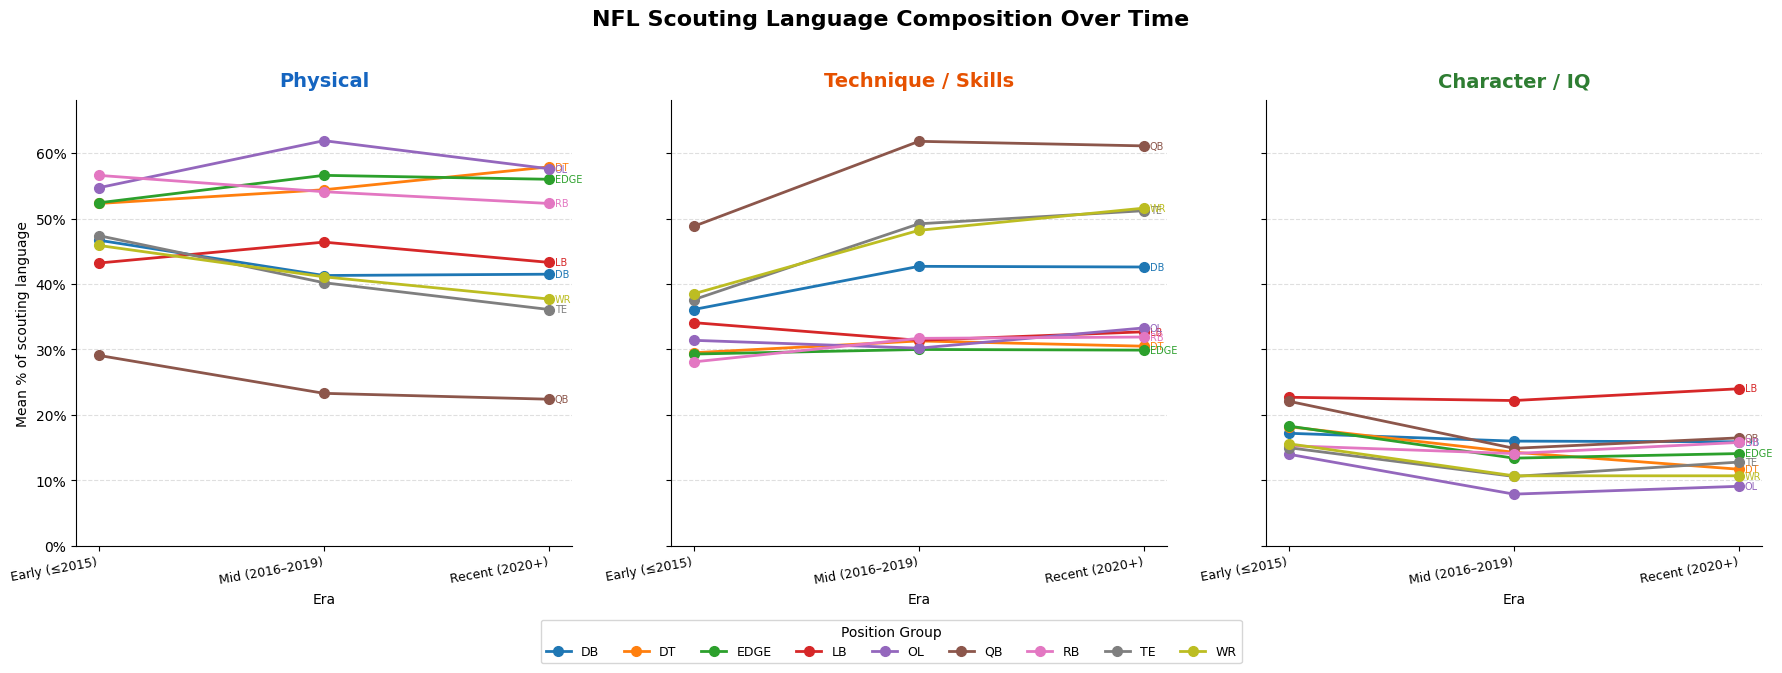

Chart saved -> ../data/processed/bin_trends_by_era.png


In [162]:
# ── 3-panel line chart — one panel per bin ──────────────────────────────────────
BIN_COLS   = ['physical_pct',  'technique_pct',    'character_pct']
BIN_TITLES = ['Physical',      'Technique / Skills', 'Character / IQ']
BIN_COLORS = ['#1565C0', '#E65100', '#2E7D32']   # deep blue, deep orange, deep green

pos_groups = sorted(era_pos['Pos_Group'].unique())

# Assign a consistent color per position group across all 3 panels
CMAP = plt.get_cmap('tab10')
pg_colors = {pg: CMAP(i) for i, pg in enumerate(pos_groups)}

# 1. CHANGED: set sharey=True for consistent scaling across panels
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# 2. OPTIONAL: Calculate a global max to ensure the labels have breathing room
global_max = era_pos[BIN_COLS].max().max()

for ax, col, title, accent in zip(axes, BIN_COLS, BIN_TITLES, BIN_COLORS):
    for pg in pos_groups:
        sub = (era_pos[era_pos['Pos_Group'] == pg]
               .sort_values('era_order'))
        if sub.empty:
            continue
        ax.plot(
            sub['era'], sub[col],
            marker='o', linewidth=2, markersize=7,
            color=pg_colors[pg], label=pg,
        )
        # Label the last point with pos group name
        last = sub.iloc[-1]
        ax.annotate(
            pg,
            xy=(last['era'], last[col]),
            xytext=(4, 0), textcoords='offset points',
            fontsize=7, va='center', color=pg_colors[pg],
        )

    # Styling
    ax.set_title(title, fontsize=14, fontweight='bold', color=accent, pad=10)
    ax.set_xlabel('Era', fontsize=10)
    
    # Only show Y label on the first plot to reduce clutter since they are shared
    if ax == axes[0]:
        ax.set_ylabel('Mean % of scouting language', fontsize=10)
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks(range(len(ERA_LABELS)))
    ax.set_xticklabels(ERA_LABELS, rotation=10, ha='right', fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    
    # 3. CHANGED: Explicitly set y-limit starting at 0 and adding 10% headroom
    ax.set_ylim(bottom=0, top=global_max * 1.1)

# Shared legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Position Group',
    loc='lower center',
    ncol=len(pos_groups),
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
)

plt.suptitle(
    'NFL Scouting Language Composition Over Time',
    fontsize=16, fontweight='bold', y=1.02,
)

# Use subplots_adjust to ensure title/legend/axes don't overlap with sharey
plt.tight_layout()

chart_path = '../data/processed/bin_trends_by_era.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved -> {chart_path}')

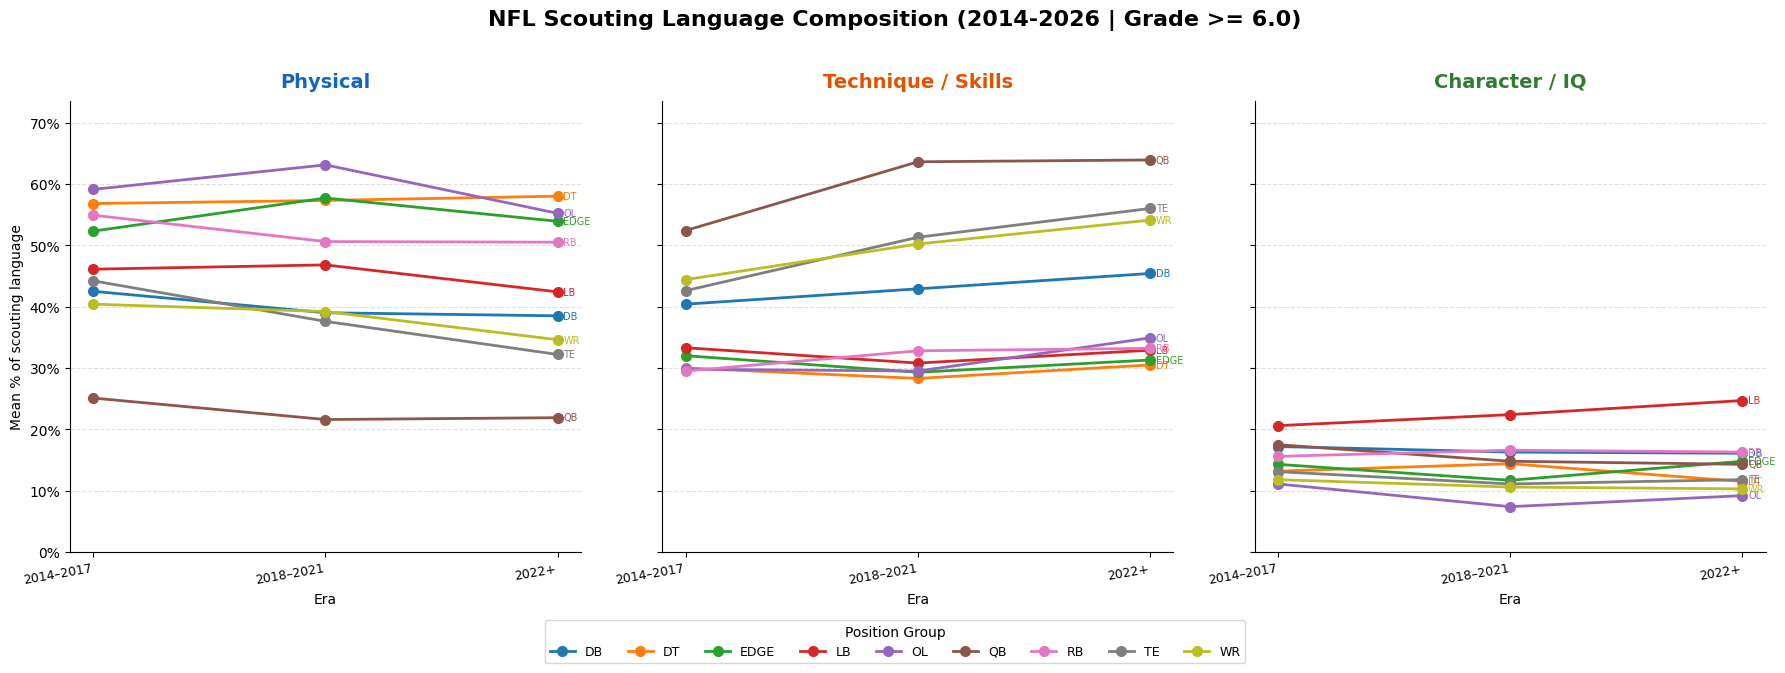

Chart saved -> ../data/processed/bin_trends_modern_high_grade.png


In [163]:
# ── Filter and Aggregate: 2014-2026 & Grade >= 6.0 ────────────────────────────
# 1. Filter raw data
mask = (df_result['year'] >= 2014) & (df_result['year'] <= 2026) & (df_result['grade'] >= 6.0)
df_filtered = df_result[mask].copy()

# 2. Define Eras for the 2014-2026 window
ERA_CUTS   = [2017, 2021] 
ERA_LABELS = [
    f'2014–{ERA_CUTS[0]}',
    f'{ERA_CUTS[0]+1}–{ERA_CUTS[1]}',
    f'{ERA_CUTS[1]+1}+'
]

def assign_era(year):
    if year <= ERA_CUTS[0]: return ERA_LABELS[0]
    elif year <= ERA_CUTS[1]: return ERA_LABELS[1]
    else: return ERA_LABELS[2]

df_filtered['era'] = df_filtered['year'].apply(assign_era)

# 3. Create era_pos aggregation
era_pos = (
    df_filtered
    .groupby(['era', 'Pos_Group'])[['physical_pct', 'technique_pct', 'character_pct']]
    .mean()
    .multiply(100)
    .round(1)
    .reset_index()
)

# Assign order for plotting
era_order = {label: i for i, label in enumerate(ERA_LABELS)}
era_pos['era_order'] = era_pos['era'].map(era_order)
era_pos = era_pos.sort_values(['era_order', 'Pos_Group']).reset_index(drop=True)

# ── 3-panel line chart — one panel per bin ──────────────────────────────────────
BIN_COLS   = ['physical_pct',  'technique_pct',    'character_pct']
BIN_TITLES = ['Physical',      'Technique / Skills', 'Character / IQ']
BIN_COLORS = ['#1565C0', '#E65100', '#2E7D32']   # deep blue, deep orange, deep green

pos_groups = sorted(era_pos['Pos_Group'].unique())

# Assign a consistent color per position group across all 3 panels
CMAP = plt.get_cmap('tab10')
pg_colors = {pg: CMAP(i) for i, pg in enumerate(pos_groups)}

# 1. CHANGED: set sharey=True for consistent scaling across panels
fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# 2. OPTIONAL: Calculate a global max to ensure the labels have breathing room
global_max = era_pos[BIN_COLS].max().max()

for ax, col, title, accent in zip(axes, BIN_COLS, BIN_TITLES, BIN_COLORS):
    for pg in pos_groups:
        sub = (era_pos[era_pos['Pos_Group'] == pg]
               .sort_values('era_order'))
        if sub.empty:
            continue
        ax.plot(
            sub['era'], sub[col],
            marker='o', linewidth=2, markersize=7,
            color=pg_colors[pg], label=pg,
        )
        # Label the last point with pos group name
        last = sub.iloc[-1]
        ax.annotate(
            pg,
            xy=(last['era'], last[col]),
            xytext=(4, 0), textcoords='offset points',
            fontsize=7, va='center', color=pg_colors[pg],
        )

    # Styling
    ax.set_title(title, fontsize=14, fontweight='bold', color=accent, pad=10)
    ax.set_xlabel('Era', fontsize=10)
    
    # Only show Y label on the first plot to reduce clutter since they are shared
    if ax == axes[0]:
        ax.set_ylabel('Mean % of scouting language', fontsize=10)
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks(range(len(ERA_LABELS)))
    ax.set_xticklabels(ERA_LABELS, rotation=10, ha='right', fontsize=9)
    ax.grid(True, axis='y', linestyle='--', alpha=0.4)
    ax.spines[['top', 'right']].set_visible(False)
    
    # 3. CHANGED: Explicitly set y-limit starting at 0 and adding 15% headroom for labels
    ax.set_ylim(bottom=0, top=global_max * 1.15)

# Shared legend below the figure
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels,
    title='Position Group',
    loc='lower center',
    ncol=len(pos_groups),
    fontsize=9,
    title_fontsize=10,
    frameon=True,
    bbox_to_anchor=(0.5, -0.08),
)

plt.suptitle(
    'NFL Scouting Language Composition (2014-2026 | Grade >= 6.0)',
    fontsize=16, fontweight='bold', y=1.02,
)

plt.tight_layout()

chart_path = '../data/processed/bin_trends_modern_high_grade.png'
plt.savefig(chart_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved -> {chart_path}')

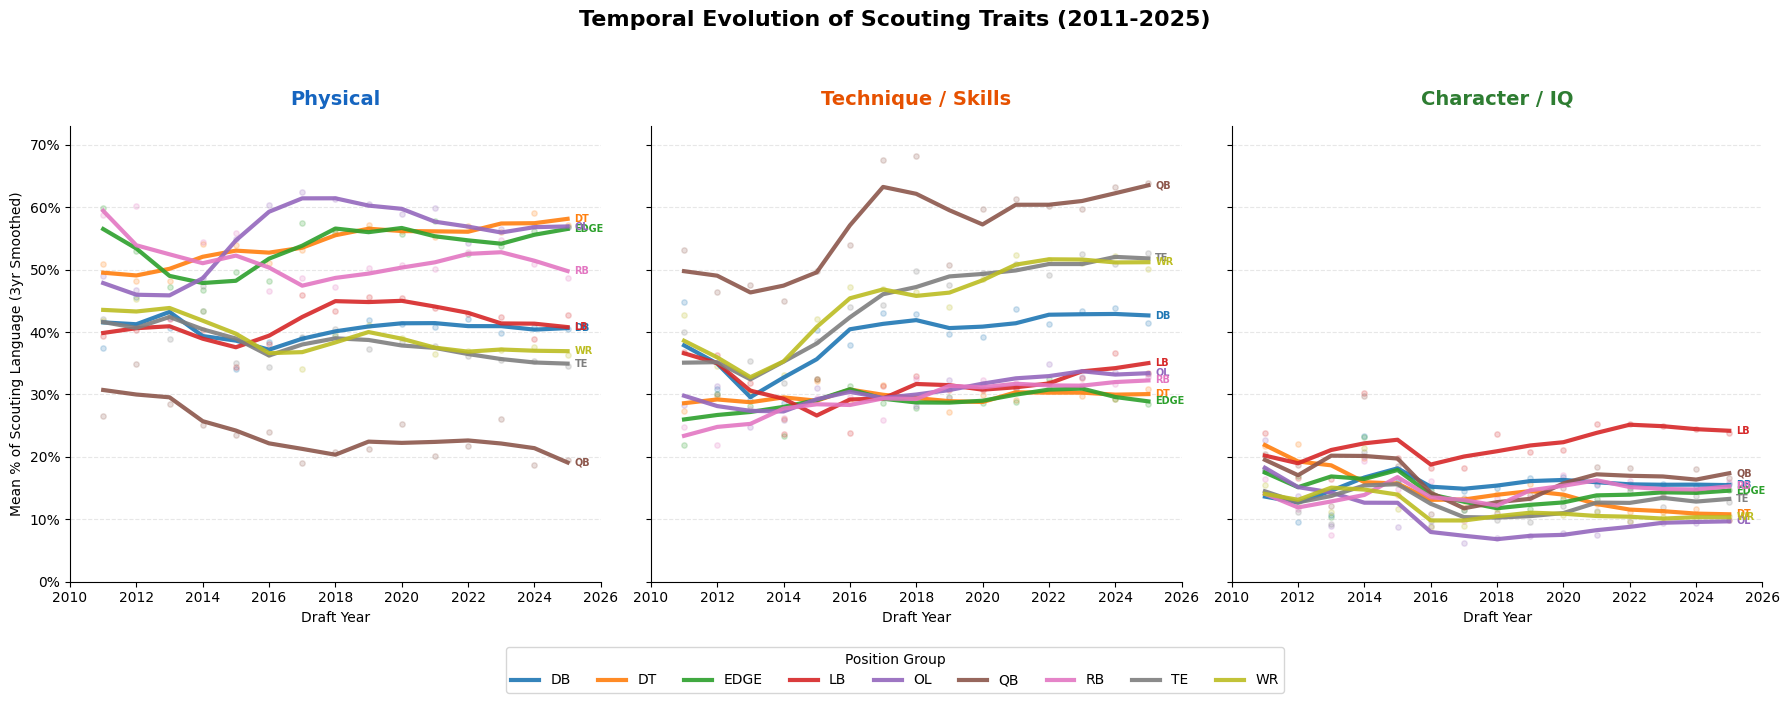

In [164]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# 1. Filter: Modern Era (2014-2026) and High-Grade Prospects (>= 6.0)
mask = (df_result['year'] >= 2011) & (df_result['year'] <= 2025) & (df_result['grade'] >= 5.5)
df_yearly = df_result[mask].copy()

# 2. Aggregate: Mean per Year per Position
# We multiply by 100 here so the smoothing happens on the percentage scale
yearly_stats = (
    df_yearly
    .groupby(['year', 'Pos_Group'])[BIN_COLS]
    .mean()
    .multiply(100)
    .reset_index()
)

# 3. Apply Smoothing (3-year rolling average per Position Group)
# min_periods=1 ensures we don't lose the start/end years (2014 and 2026)
yearly_stats = yearly_stats.sort_values(['Pos_Group', 'year'])
for col in BIN_COLS:
    yearly_stats[f'{col}_smooth'] = (
        yearly_stats.groupby('Pos_Group')[col]
        .transform(lambda x: x.rolling(window=3, center=True, min_periods=1).mean())
    )

# ── 3-panel line chart — Yearly Smoothed ──────────────────────────────────────
BIN_TITLES = ['Physical', 'Technique / Skills', 'Character / IQ']
BIN_COLORS = ['#1565C0', '#E65100', '#2E7D32']
pos_groups = sorted(yearly_stats['Pos_Group'].unique())

# Consistent color mapping
CMAP = plt.get_cmap('tab10')
pg_colors = {pg: CMAP(i) for i, pg in enumerate(pos_groups)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Calculate global max for shared Y-axis headroom
global_max = yearly_stats[[f'{c}_smooth' for c in BIN_COLS]].max().max()

for ax, col, title, accent in zip(axes, BIN_COLS, BIN_TITLES, BIN_COLORS):
    smooth_col = f'{col}_smooth'
    
    for pg in pos_groups:
        sub = yearly_stats[yearly_stats['Pos_Group'] == pg]
        
        # Plot the smoothed line
        ax.plot(
            sub['year'], sub[smooth_col],
            marker=None, linewidth=3, alpha=0.9,
            color=pg_colors[pg], label=pg
        )
        
        # Optional: Plot the raw yearly dots at lower opacity to show the "truth"
        ax.scatter(
            sub['year'], sub[col],
            color=pg_colors[pg], s=15, alpha=0.2
        )
        
        # Annotate the final year
        last = sub.iloc[-1]
        ax.annotate(
            pg, xy=(last['year'], last[smooth_col]),
            xytext=(5, 0), textcoords='offset points',
            fontsize=7, va='center', color=pg_colors[pg], fontweight='bold'
        )

    # Styling
    ax.set_title(title, fontsize=14, fontweight='bold', color=accent, pad=15)
    ax.set_xlabel('Draft Year', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel('Mean % of Scouting Language (3yr Smoothed)', fontsize=10)
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks(range(2010, 2027, 2)) # Major ticks every 2 years
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    
    # Unified Y-limit with headroom
    ax.set_ylim(0, global_max * 1.15)

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles, labels, title='Position Group',
    loc='lower center', ncol=len(pos_groups),
    bbox_to_anchor=(0.5, -0.1), frameon=True
)

plt.suptitle(
    'Temporal Evolution of Scouting Traits (2011-2025)',
    fontsize=16, fontweight='bold', y=1.05
)

plt.tight_layout()
plt.show()

Source: 'strengths'  |  players: 1652  |  columns: ['str_physical_pct', 'str_technique_pct', 'str_character_pct']


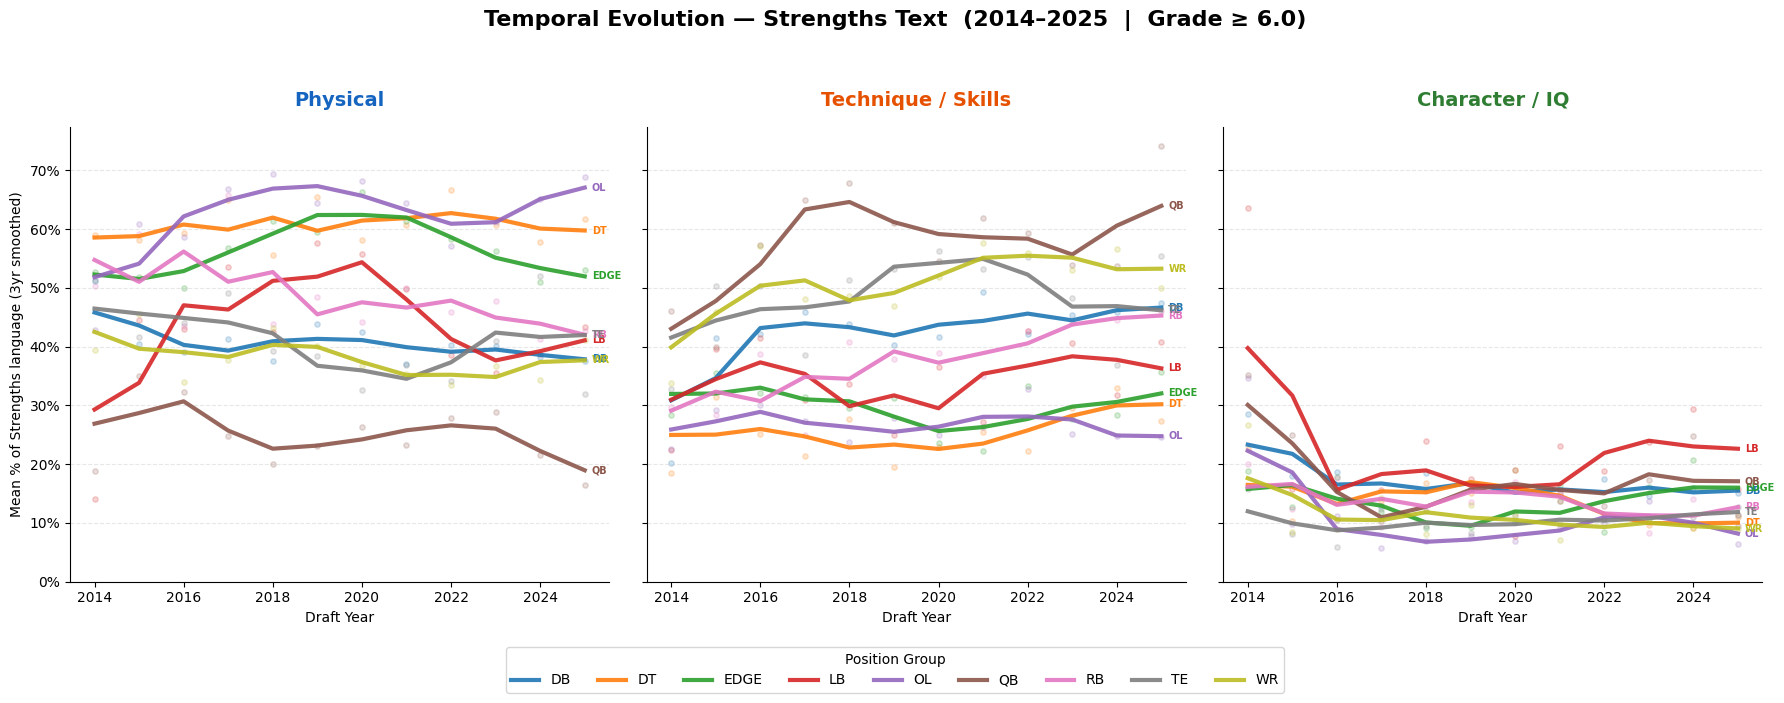

In [165]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── TOGGLE SETTINGS ───────────────────────────────────────────────────────────
TEXT_SOURCE = 'strengths'   # 'combined' | 'strengths' | 'weaknesses'
YEAR_RANGE  = (2014, 2025)
MIN_GRADE   = 6.0
# ─────────────────────────────────────────────────────────────────────────────

# Map toggle → column prefix
_PREFIX = {'combined': '', 'strengths': 'str_', 'weaknesses': 'wk_'}
if TEXT_SOURCE not in _PREFIX:
    raise ValueError(f"TEXT_SOURCE must be one of {list(_PREFIX)}, got '{TEXT_SOURCE}'")

prefix    = _PREFIX[TEXT_SOURCE]
BIN_COLS_SRC  = [f'{prefix}physical_pct', f'{prefix}technique_pct', f'{prefix}character_pct']
TOTAL_COL = f'{prefix}total_matched'

# 1. Filter
mask = (
    (df_result['year'] >= YEAR_RANGE[0]) &
    (df_result['year'] <= YEAR_RANGE[1]) &
    (df_result['grade'] >= MIN_GRADE) &
    (df_result[TOTAL_COL] > 0)          # exclude zero-match rows for this source
)
df_yearly = df_result[mask].copy()
print(f'Source: {TEXT_SOURCE!r}  |  players: {len(df_yearly)}  |  columns: {BIN_COLS_SRC}')

# 2. Aggregate: mean per year × position group
yearly_stats = (
    df_yearly
    .groupby(['year', 'Pos_Group'])[BIN_COLS_SRC]
    .mean()
    .multiply(100)
    .reset_index()
)

# 3. 3-year rolling average per position group
yearly_stats = yearly_stats.sort_values(['Pos_Group', 'year'])
for col in BIN_COLS_SRC:
    yearly_stats[f'{col}_smooth'] = (
        yearly_stats.groupby('Pos_Group')[col]
        .transform(lambda x: x.rolling(window=3, center=True, min_periods=1).mean())
    )

# ── Chart ─────────────────────────────────────────────────────────────────────
BIN_TITLES = ['Physical', 'Technique / Skills', 'Character / IQ']
BIN_COLORS = ['#1565C0', '#E65100', '#2E7D32']
pos_groups = sorted(yearly_stats['Pos_Group'].unique())

CMAP = plt.get_cmap('tab10')
pg_colors = {pg: CMAP(i) for i, pg in enumerate(pos_groups)}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

smooth_cols = [f'{c}_smooth' for c in BIN_COLS_SRC]
global_max  = yearly_stats[smooth_cols].max().max()

for ax, col, title, accent in zip(axes, BIN_COLS_SRC, BIN_TITLES, BIN_COLORS):
    smooth_col = f'{col}_smooth'

    for pg in pos_groups:
        sub = yearly_stats[yearly_stats['Pos_Group'] == pg]
        if sub.empty:
            continue
        ax.plot(sub['year'], sub[smooth_col], linewidth=3, alpha=0.9,
                color=pg_colors[pg], label=pg)
        ax.scatter(sub['year'], sub[col], color=pg_colors[pg], s=15, alpha=0.2)

        last = sub.iloc[-1]
        ax.annotate(pg, xy=(last['year'], last[smooth_col]),
                    xytext=(5, 0), textcoords='offset points',
                    fontsize=7, va='center', color=pg_colors[pg], fontweight='bold')

    ax.set_title(title, fontsize=14, fontweight='bold', color=accent, pad=15)
    ax.set_xlabel('Draft Year', fontsize=10)
    if ax == axes[0]:
        ax.set_ylabel(f'Mean % of {TEXT_SOURCE.title()} language (3yr smoothed)', fontsize=10)

    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
    ax.set_xticks(range(YEAR_RANGE[0], YEAR_RANGE[1] + 1, 2))
    ax.grid(True, axis='y', linestyle='--', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_ylim(0, global_max * 1.15)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='Position Group', loc='lower center',
           ncol=len(pos_groups), bbox_to_anchor=(0.5, -0.1), frameon=True)

plt.suptitle(
    f'Temporal Evolution — {TEXT_SOURCE.title()} Text  '
    f'({YEAR_RANGE[0]}–{YEAR_RANGE[1]}  |  Grade ≥ {MIN_GRADE})',
    fontsize=16, fontweight='bold', y=1.05,
)
plt.tight_layout()
plt.show()

## Section 10 — Per-Position Breakdown

One figure per position group, three panels each: physical / technique / character.

Saved → ../data/processed/pos_breakdown_db.png


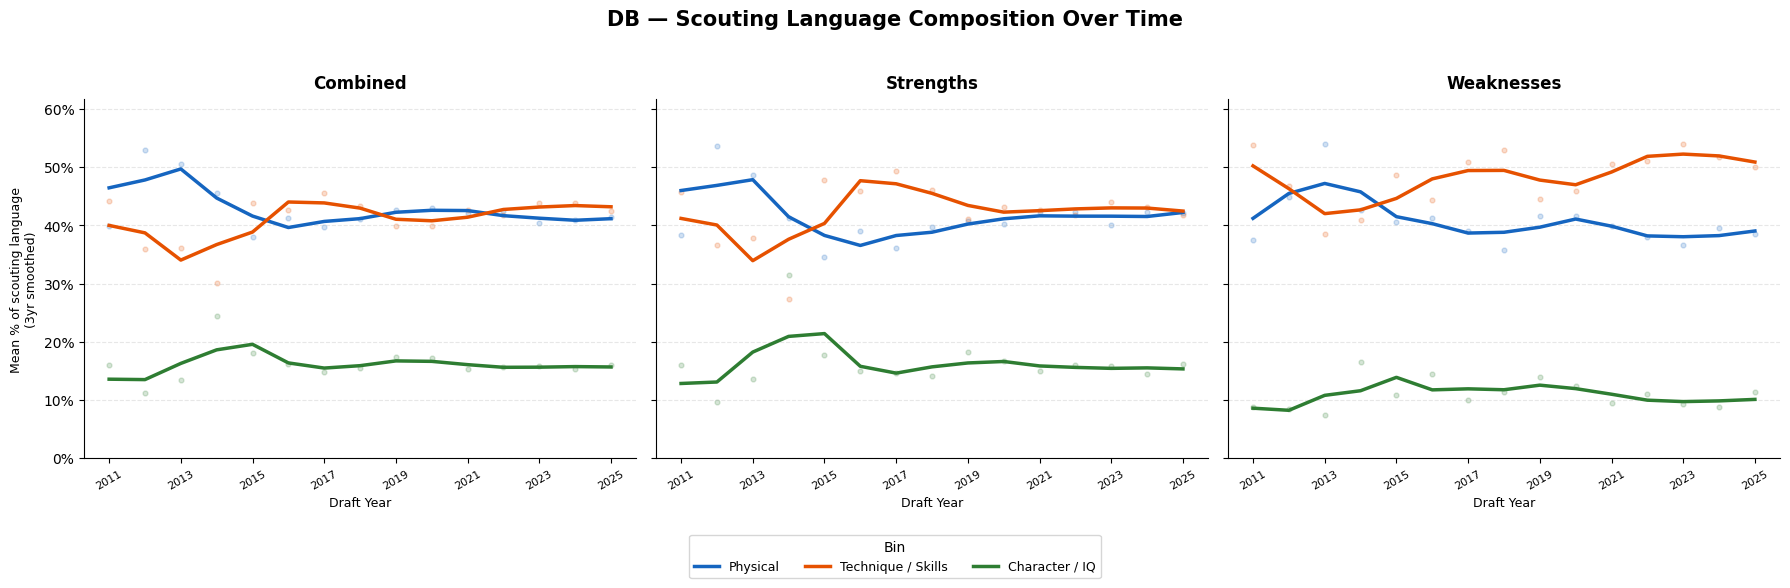

Saved → ../data/processed/pos_breakdown_dt.png


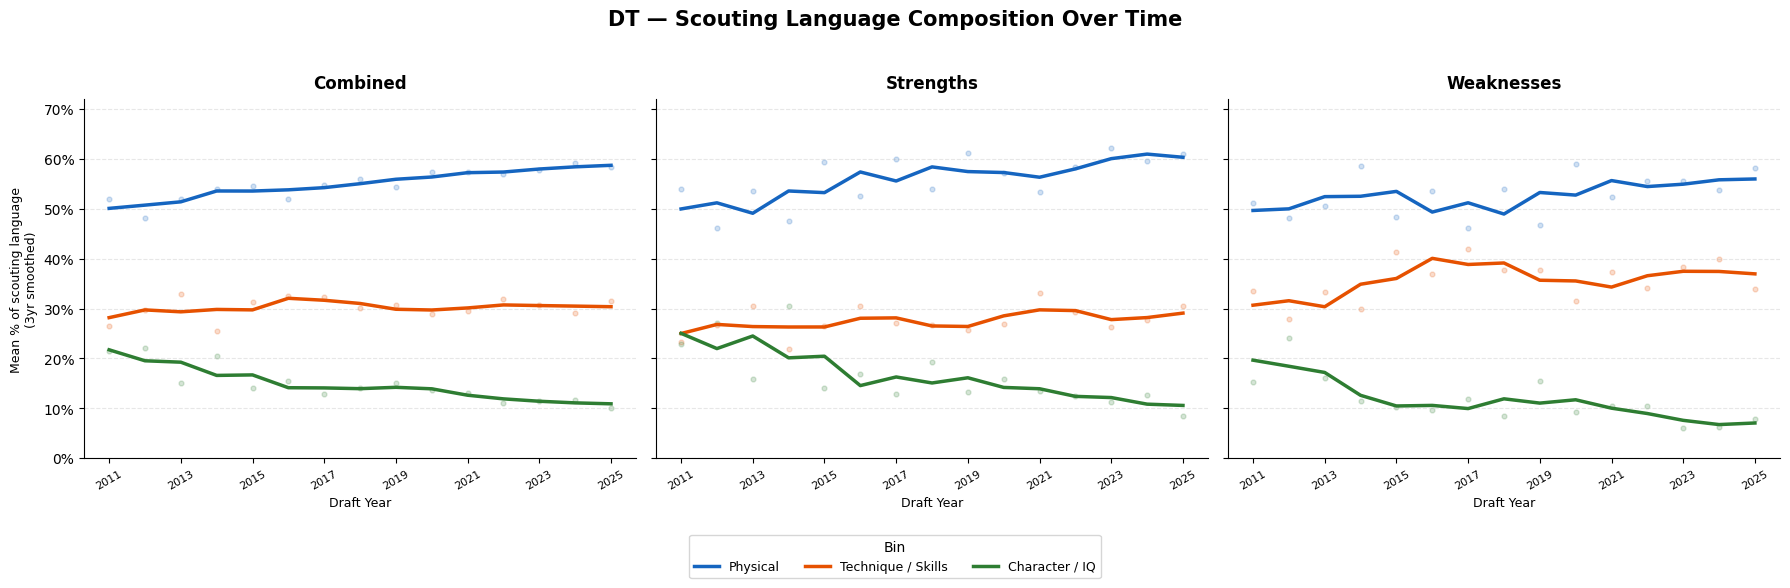

Saved → ../data/processed/pos_breakdown_edge.png


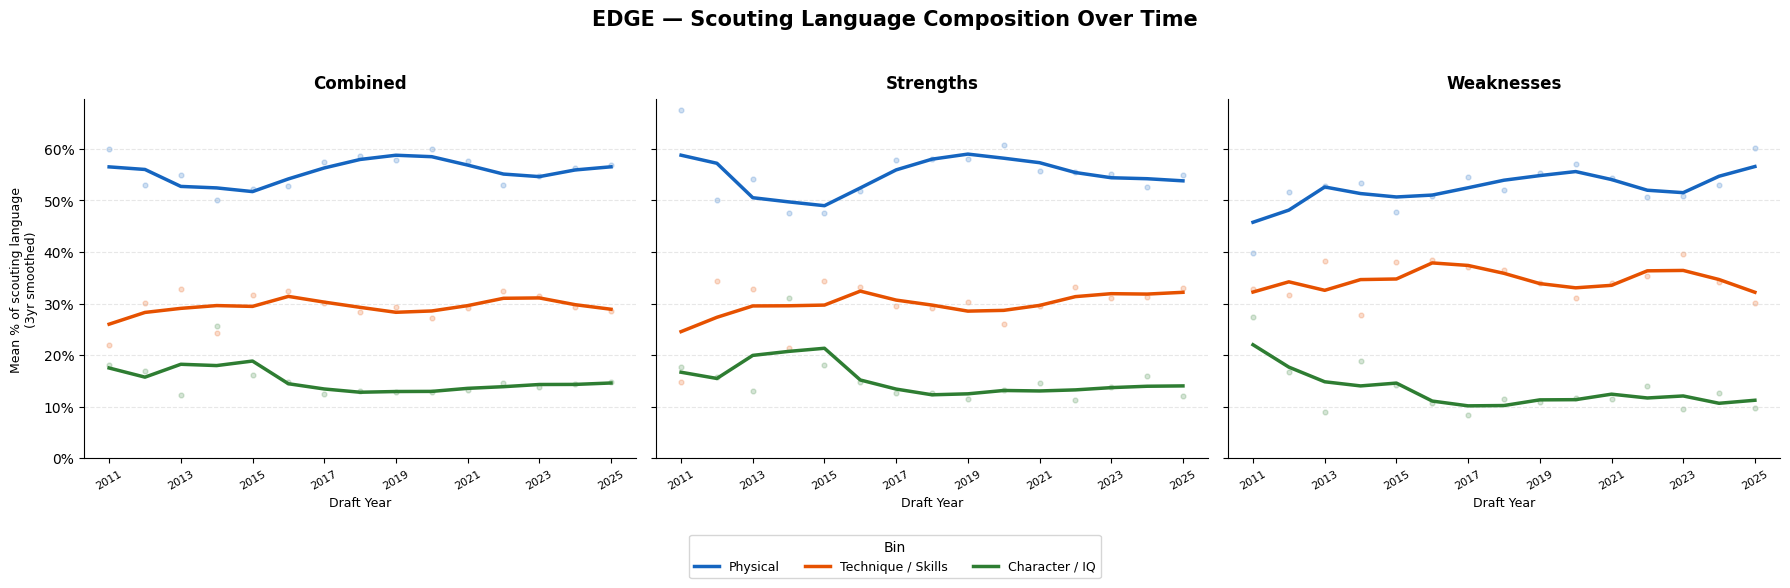

Saved → ../data/processed/pos_breakdown_lb.png


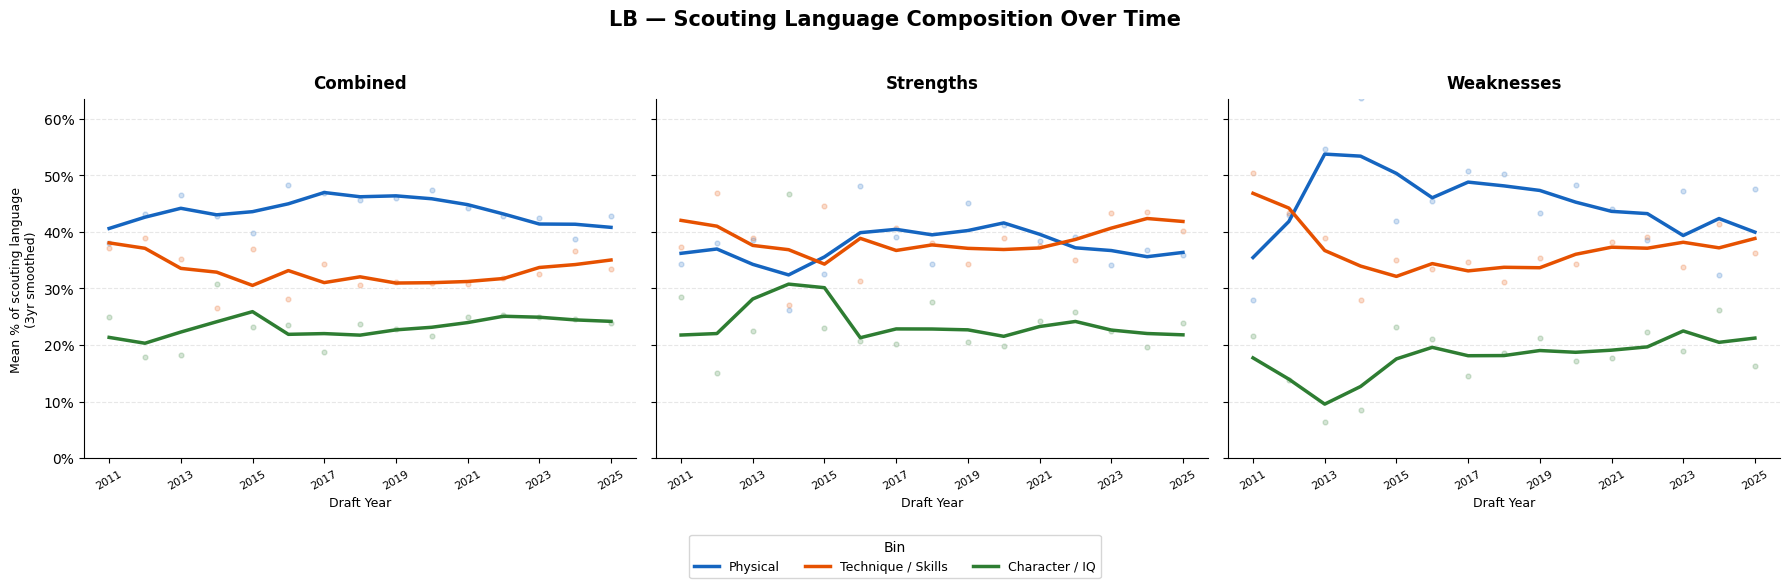

Saved → ../data/processed/pos_breakdown_ol.png


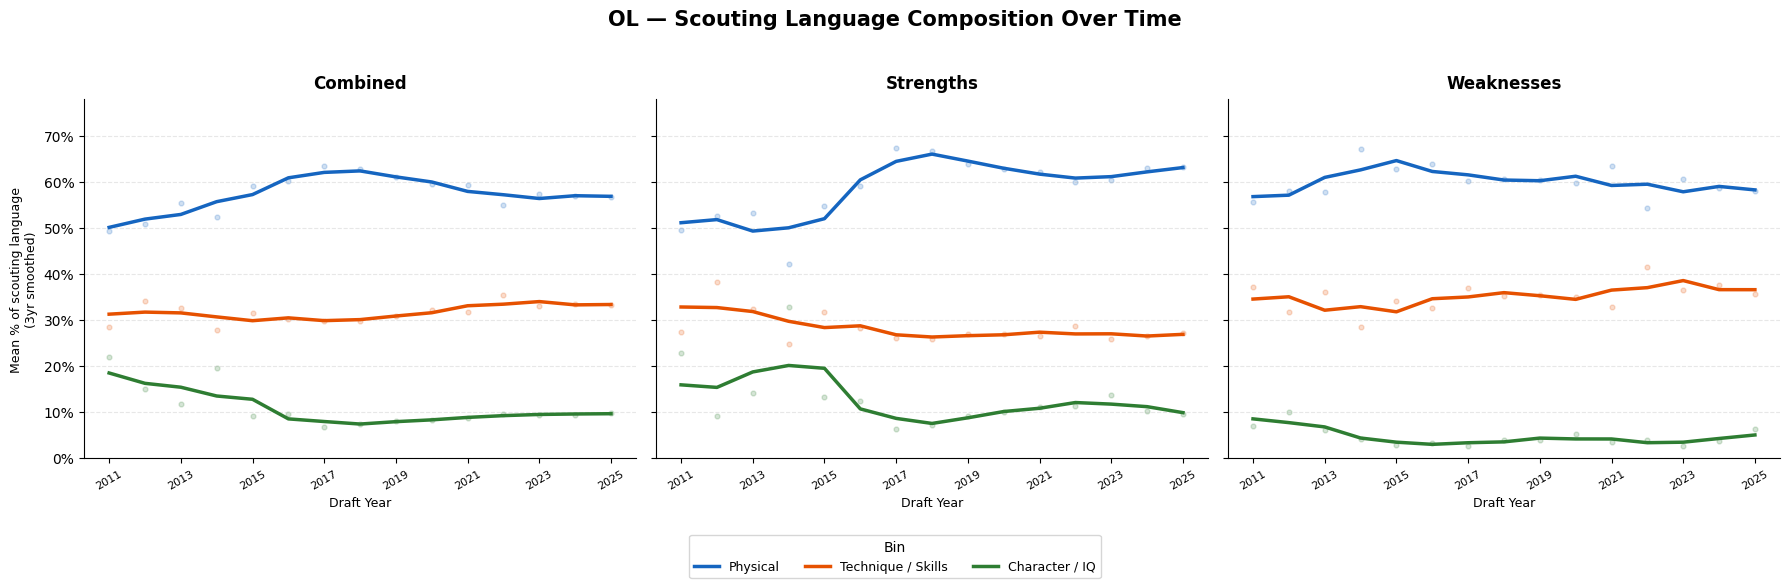

Saved → ../data/processed/pos_breakdown_qb.png


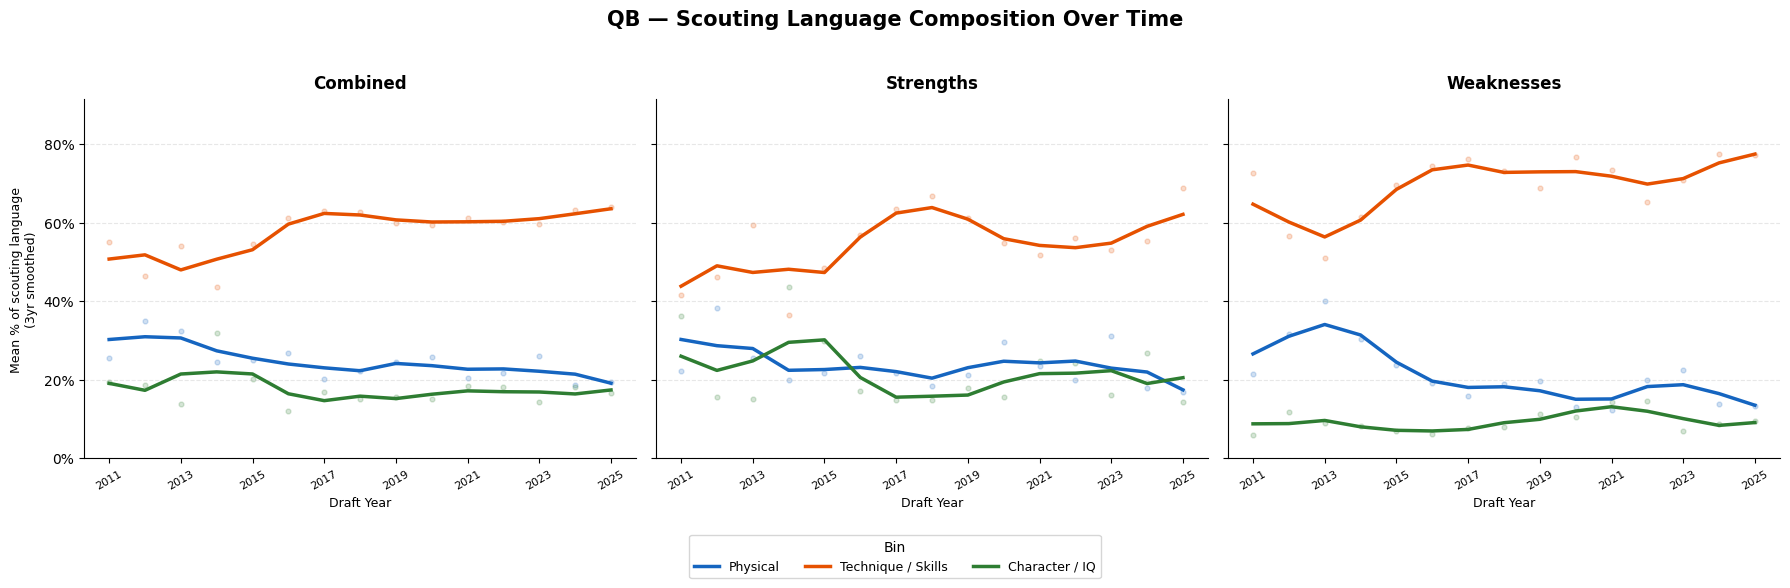

Saved → ../data/processed/pos_breakdown_rb.png


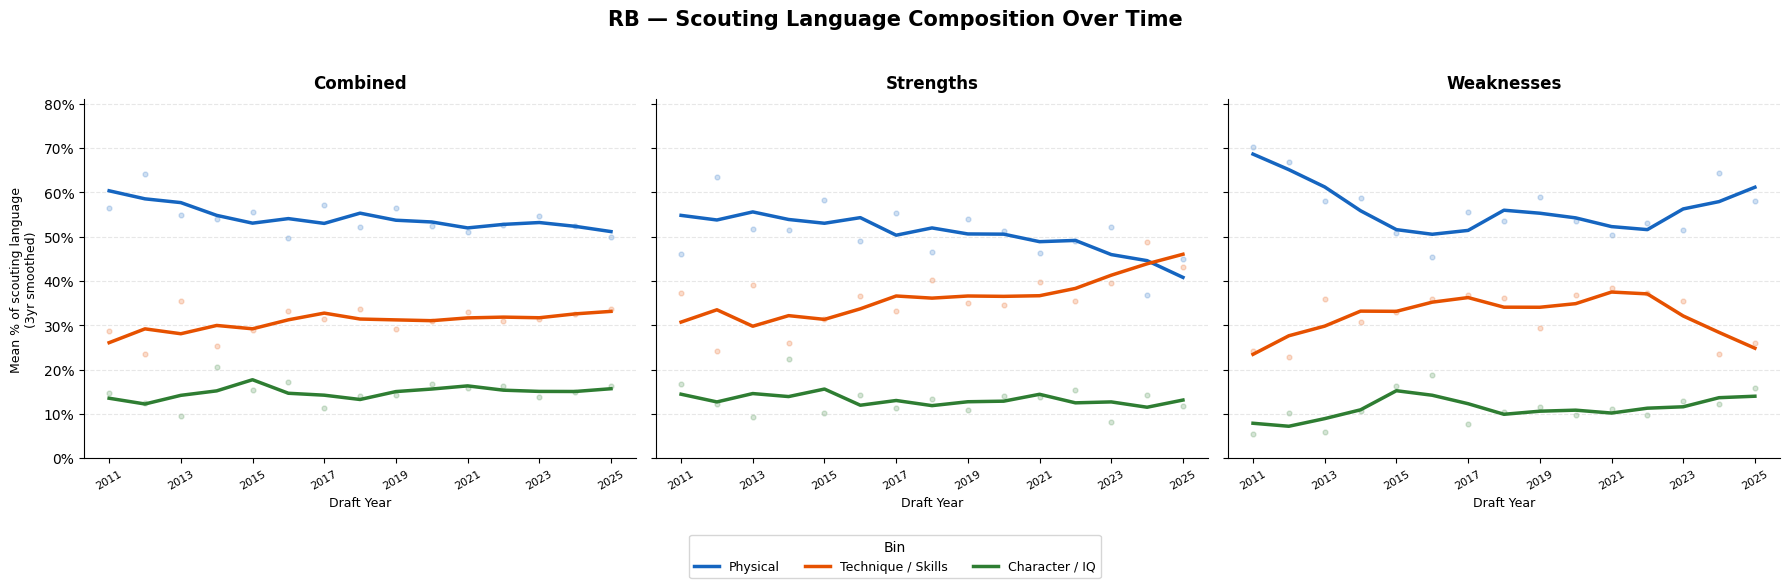

Saved → ../data/processed/pos_breakdown_te.png


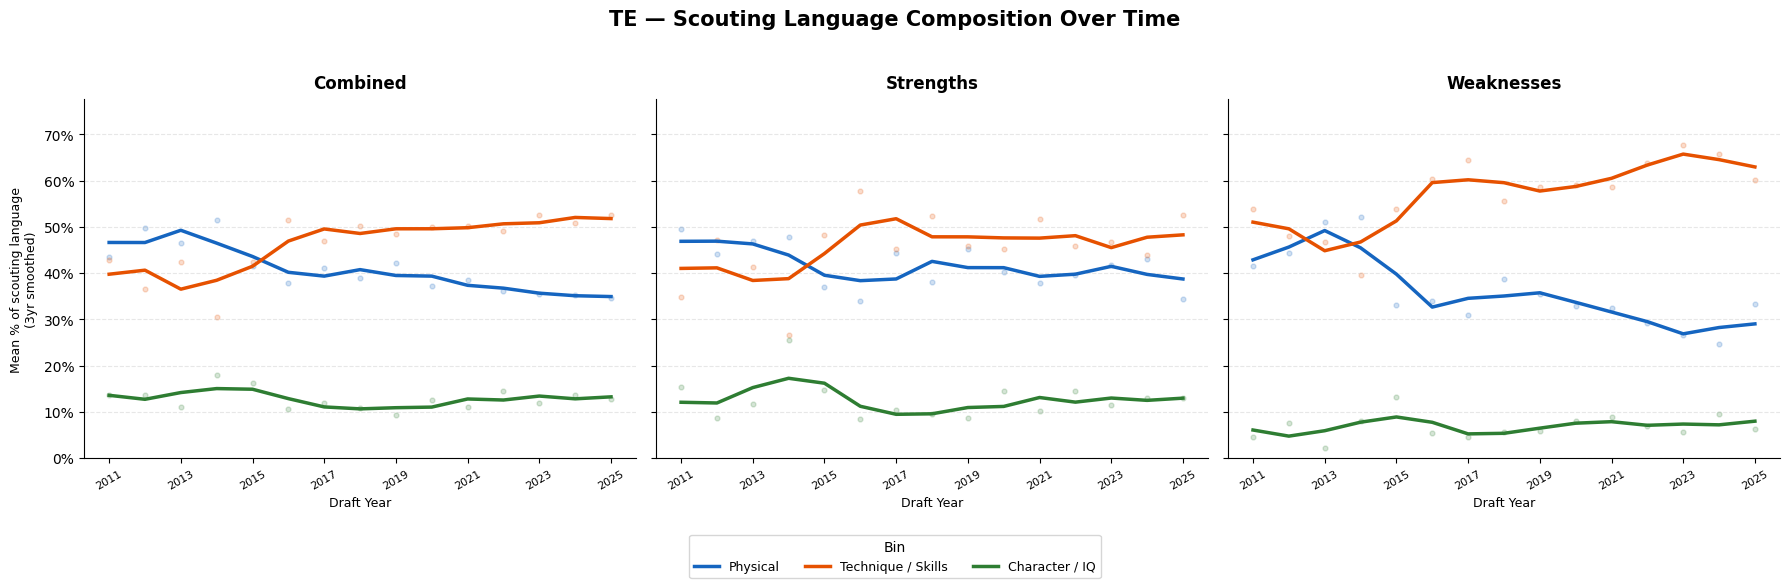

Saved → ../data/processed/pos_breakdown_wr.png


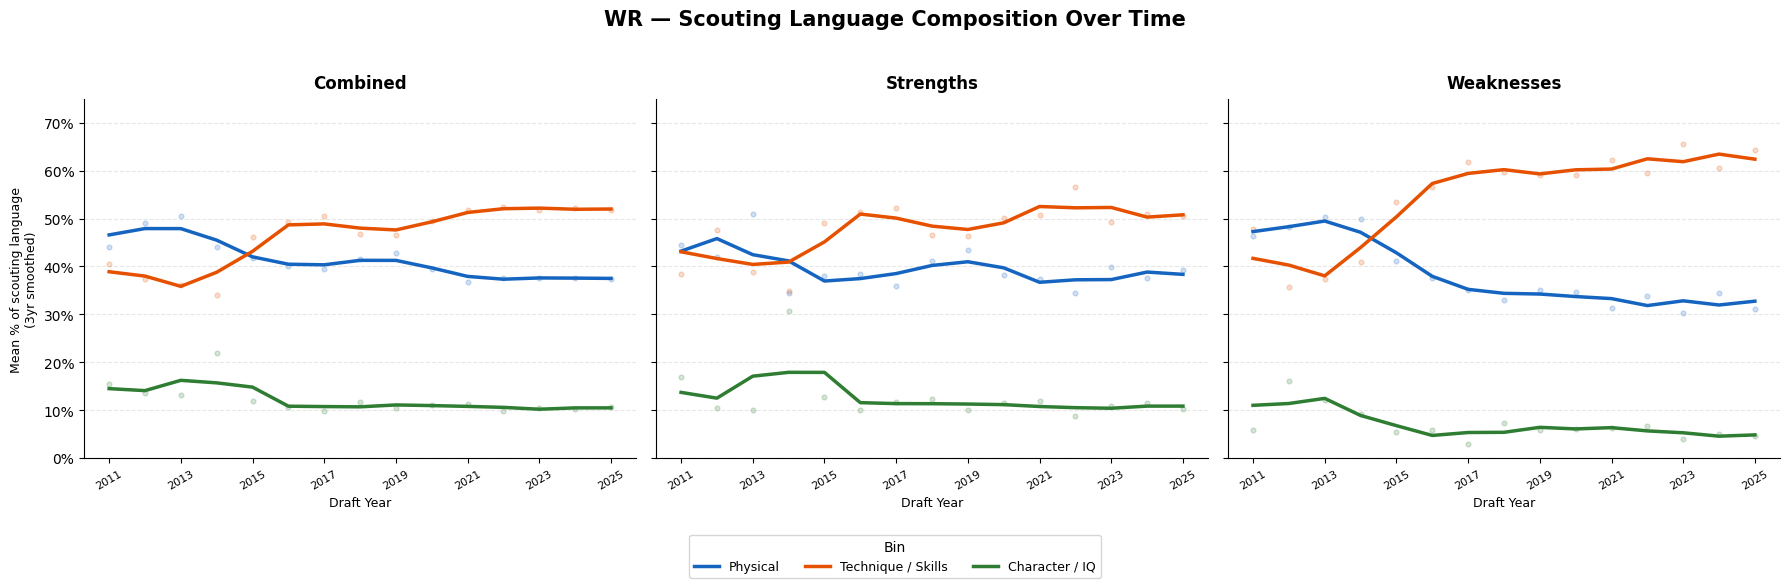

In [166]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Config ────────────────────────────────────────────────────────────────────
YEAR_RANGE    = (2011, 2025)
MIN_GRADE     = 0
SMOOTH_WINDOW = 3            # years in rolling average
SAVE_CHARTS   = True        # set True to save one PNG per position group

# Text sources: (column prefix, total_matched col, panel title)
SOURCES = [
    ('',     'total_matched',     'Combined'),
    ('str_', 'str_total_matched', 'Strengths'),
    ('wk_',  'wk_total_matched',  'Weaknesses'),
]

# Bins: (pct column suffix, display label, color)
BINS = [
    ('physical_pct',  'Physical',          '#1565C0'),
    ('technique_pct', 'Technique / Skills','#E65100'),
    ('character_pct', 'Character / IQ',    '#2E7D32'),
]

# ── Loop over positions ───────────────────────────────────────────────────────
pos_groups = sorted(df_result['Pos_Group'].dropna().unique())

for pg in pos_groups:
    base_mask = (
        (df_result['year']      >= YEAR_RANGE[0]) &
        (df_result['year']      <= YEAR_RANGE[1]) &
        (df_result['grade']     >= MIN_GRADE)      &
        (df_result['Pos_Group'] == pg)
    )
    df_pg = df_result[base_mask].copy()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
    fig.suptitle(
        f'{pg} — Scouting Language Composition Over Time',
        fontsize=15, fontweight='bold', y=1.03,
    )

    global_max = 0   # will be used to set a shared y-limit after all panels are drawn

    for ax, (prefix, total_col, panel_title) in zip(axes, SOURCES):
        # Drop players with zero keyword matches for this specific source
        df_src = df_pg[df_pg[total_col] > 0].copy()

        bin_cols = [f'{prefix}{suf}' for suf, _, _ in BINS]

        # Aggregate: mean per year
        yearly = (
            df_src
            .groupby('year')[bin_cols]
            .mean()
            .multiply(100)
            .reset_index()
            .sort_values('year')
        )

        # 3-year rolling smooth
        for col in bin_cols:
            yearly[f'{col}_smooth'] = (
                yearly[col]
                .rolling(window=SMOOTH_WINDOW, center=True, min_periods=1)
                .mean()
            )

        panel_max = yearly[[f'{c}_smooth' for c in bin_cols]].max().max()
        if not np.isnan(panel_max):
            global_max = max(global_max, panel_max)

        # Draw one line per bin
        for col_suf, bin_label, color in BINS:
            col    = f'{prefix}{col_suf}'
            smooth = f'{col}_smooth'
            if col not in yearly.columns or yearly.empty:
                continue
            ax.plot(yearly['year'], yearly[smooth],
                    linewidth=2.5, color=color, label=bin_label)
            ax.scatter(yearly['year'], yearly[col],
                       color=color, s=12, alpha=0.2)

        ax.set_title(panel_title, fontsize=12, fontweight='bold', pad=8)
        ax.set_xlabel('Draft Year', fontsize=9)
        if ax == axes[0]:
            ax.set_ylabel('Mean % of scouting language\n(3yr smoothed)', fontsize=9)

        ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x:.0f}%'))
        ax.set_xticks(range(YEAR_RANGE[0], YEAR_RANGE[1] + 1, 2))
        ax.tick_params(axis='x', rotation=30, labelsize=8)
        ax.grid(True, axis='y', linestyle='--', alpha=0.3)
        ax.spines[['top', 'right']].set_visible(False)

    # Apply shared y-limit across all three panels
    y_top = max(global_max * 1.18, 10)   # floor at 10% so empty charts still render
    for ax in axes:
        ax.set_ylim(0, y_top)

    # Shared bin legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels,
        title='Bin', loc='lower center',
        ncol=3, bbox_to_anchor=(0.5, -0.12),
        fontsize=9, title_fontsize=10, frameon=True,
    )

    plt.tight_layout()

    if SAVE_CHARTS:
        out = f'../data/processed/pos_breakdown_{pg.lower()}.png'
        plt.savefig(out, dpi=150, bbox_inches='tight')
        print(f'Saved → {out}')

    plt.show()

## Section 11 — Scouting Report Text Colorizer

For each position group, two players are selected and their scouting report text is
rendered with color-coded highlighting to show which tokens matched each bin.

In [167]:
from collections import Counter

# ── Config ─────────────────────────────────────────────────────────────────────
TOP_N        = 40    # top N uncovered tokens to show per position
MIN_FREQ     = 5     # ignore tokens appearing fewer than N times across pos group
MIN_TOKEN_LEN = 3    # skip very short tokens (noise)

# All tokens currently covered
all_covered = set().union(*KEYWORD_SETS.values())

# ── For each position group, find the most frequent uncovered tokens ────────────
print(f'{"POS":<8} {"RANK":<5} {"TOKEN":<30} {"FREQ":>6}')
print('-' * 55)

for pos_group in sorted(df['Pos_Group'].dropna().astype(str).unique()):
    pos_rows = df[df['Pos_Group'] == pos_group]
    # Combine all preprocessed tokens for this position
    counter = Counter()
    for token_list in pos_rows['all_tokens']:
        if isinstance(token_list, list):
            counter.update(token_list)

    # Filter: not covered, long enough, frequent enough
    candidates = [
        (tok, freq) for tok, freq in counter.most_common()
        if tok not in all_covered
        and len(tok) >= MIN_TOKEN_LEN
        and freq >= MIN_FREQ
    ]

    print(f'\n── {pos_group} (top {TOP_N} uncovered) ──')
    for rank, (tok, freq) in enumerate(candidates[:TOP_N], 1):
        print(f'  {rank:<4} {tok:<35} {freq:>5}')

POS      RANK  TOKEN                            FREQ
-------------------------------------------------------

── DB (top 40 uncovered) ──
  1    receiver                             1585
  2    play                                 1404
  3    safety                               1291
  4    off                                   904
  5    team                                  884
  6    field                                 874
  7    could                                 864
  8    run_support                           821
  9    over                                  757
  10   zone                                  732
  11   lack                                  697
  12   out                                   677
  13   back                                  664
  14   cornerback                            659
  15   high                                  631
  16   long                                  617
  17   down                                  595
  18   big                   

In [168]:
from IPython.display import display, HTML
import re as _re

# ── Config ─────────────────────────────────────────────────────────────────────
EARLY_YR   = 2013    # strictly 2013
LATE_YR    = 2025    # strictly 2025
EARLY_POOL = [2013, 2014]          # allow one year buffer for early
LATE_POOL  = [2024, 2025]          # allow one year buffer for late
MIN_GRADE  = 6.0

# Which text sections to display
SHOW_SECTIONS = ['overview', 'strengths', 'weaknesses']

# ── Palette (matches existing notebook) ────────────────────────────────────────
_BIN_COLOR = {
    'physical':  '#1565C0',
    'technique': '#E65100',
    'character': '#2E7D32',
    'none':      '#AAAAAA',
}
_BIN_LABEL = {
    'physical':  'Physical',
    'technique': 'Technique / Skills',
    'character': 'Character / IQ',
}

# ── Build phrase → bin lookup from CURATED_PHRASE_MAP ─────────────────────────
# Maps e.g. "route running" → ('technique', 'route_running')
_PHRASE_BIN = {}
for raw_phrase, stitched in CURATED_PHRASE_MAP.items():
    for bin_name, kws in KEYWORD_SETS.items():
        if stitched in kws:
            _PHRASE_BIN[raw_phrase.lower()] = (bin_name, stitched)
            break

# Sort longest-first so greedy matching picks "route running" before "route"
_PHRASE_LIST = sorted(_PHRASE_BIN.keys(), key=len, reverse=True)

# ── Colorize raw text ──────────────────────────────────────────────────────────
def _bin_of_word(word: str) -> str:
    token = lemmatizer.lemmatize(word.lower())
    for bn, kws in KEYWORD_SETS.items():
        if token in kws:
            return bn
    return 'none'

def _span(text: str, bin_name: str) -> str:
    c = _BIN_COLOR[bin_name]
    w = 'bold' if bin_name != 'none' else 'normal'
    return f'<span style="color:{c};font-weight:{w}">{text}</span>'

def _colorize(raw_text: str) -> str:
    if not isinstance(raw_text, str) or not raw_text.strip():
        return '<em style="color:#666">—</em>'

    # Work on a lowercased copy for matching, but emit original chars
    text    = raw_text
    lo_text = raw_text.lower()
    parts   = []
    i       = 0

    while i < len(text):
        # 1. Try multi-word phrase match first
        matched_phrase = False
        for phrase in _PHRASE_LIST:
            if lo_text.startswith(phrase, i):
                bin_name = _PHRASE_BIN[phrase][0]
                parts.append(_span(text[i:i+len(phrase)], bin_name))
                i += len(phrase)
                matched_phrase = True
                break
        if matched_phrase:
            continue

        # 2. Non-word character — pass through as-is
        if not text[i].isalpha() and text[i] != "'":
            parts.append(text[i])
            i += 1
            continue

        # 3. Single word
        m = _re.match(r"[\w']+", text[i:])
        if m:
            word = m.group()
            parts.append(_span(word, _bin_of_word(word)))
            i += len(word)
        else:
            parts.append(text[i])
            i += 1

    return ''.join(parts)

# ── One player card ────────────────────────────────────────────────────────────
def _section_html(title: str, raw: str) -> str:
    if not isinstance(raw, str) or not raw.strip():
        return ''
    return (
        f'<p style="margin:10px 0 3px 0;font-size:11px;font-weight:700;'
        f'text-transform:uppercase;letter-spacing:.06em;color:#888">{title}</p>'
        f'<p style="margin:0 0 12px 0;font-size:13px;line-height:1.75">{_colorize(raw)}</p>'
    )

def _player_card(row) -> str:
    name  = row['player_name']
    pos   = row.get('position', row.get('Pos_Group', ''))
    yr    = int(row['year'])
    grade = row.get('grade', 'N/A')
    if isinstance(grade, float) and grade == grade:
        grade = f'{grade:.2f}'

    p_pct = float(row['physical_pct'])  * 100
    t_pct = float(row['technique_pct']) * 100
    c_pct = float(row['character_pct']) * 100

    bar = ''.join(
        f'<div style="display:inline-block;width:{pct:.1f}%;background:{_BIN_COLOR[b]};'
        f'height:12px" title="{_BIN_LABEL[b]}: {pct:.1f}%"></div>'
        for b, pct in [('physical', p_pct), ('technique', t_pct), ('character', c_pct)]
    )
    legend = ''.join(
        f'<span style="display:inline-block;margin-right:16px;font-size:12px">'
        f'<span style="background:{_BIN_COLOR[b]};color:#fff;padding:2px 7px;'
        f'border-radius:3px;font-size:11px">{_BIN_LABEL[b]}</span>&nbsp;{pct:.1f}%</span>'
        for b, pct in [('physical', p_pct), ('technique', t_pct), ('character', c_pct)]
    )

    body = ''.join(_section_html(s.capitalize(), row.get(s, '')) for s in SHOW_SECTIONS)

    return f"""
    <div style="border:1px solid #444;border-radius:8px;padding:18px 22px;
                margin:10px 0;font-family:'Segoe UI',Arial,sans-serif;max-width:900px">
      <div style="display:flex;justify-content:space-between;align-items:baseline;
                  border-bottom:2px solid #444;padding-bottom:8px;margin-bottom:14px">
        <span style="font-size:17px;font-weight:700">{name}</span>
        <span style="font-size:12px;color:#999">{pos} &nbsp;·&nbsp; {yr} Draft &nbsp;·&nbsp; Grade&nbsp;{grade}</span>
      </div>
      {body}
      <div style="margin-top:14px;border-top:1px solid #444;padding-top:10px">
        <div style="width:100%;border-radius:4px;overflow:hidden;margin-bottom:7px">{bar}</div>
        {legend}
      </div>
    </div>"""

# ── Merge text back onto df_result ─────────────────────────────────────────────
_text_cols = ['player_name'] + SHOW_SECTIONS
_df_vis = df_result.merge(
    df[_text_cols].drop_duplicates('player_name'),
    on='player_name', how='left'
)

# ── Player selection ───────────────────────────────────────────────────────────
def _pick_pair(grp):
    """Return (early_row, late_row): grade >= MIN_GRADE, most contrasting physical_pct."""
    grp = grp[grp['grade'] >= MIN_GRADE]
    early_pool = grp[grp['year'].isin(EARLY_POOL)]
    late_pool  = grp[grp['year'].isin(LATE_POOL)]
    if early_pool.empty or late_pool.empty:
        return None, None
    best_diff, best_e, best_l = -1, None, None
    for _, e in early_pool.iterrows():
        for _, l in late_pool.iterrows():
            diff = abs(float(e['physical_pct']) - float(l['physical_pct']))
            if diff > best_diff:
                best_diff, best_e, best_l = diff, e, l
    return best_e, best_l

# ── Render ──────────────────────────────────────────────────────────────────────
html_out = []
skipped  = []

for pos_group, grp in _df_vis.groupby('Pos_Group'):
    early, late = _pick_pair(grp)
    if early is None:
        skipped.append(pos_group)
        continue
    html_out.append(
        f'<h2 style="font-family:\'Segoe UI\',Arial,sans-serif;margin:36px 0 4px 0;'
        f'font-size:15px;font-weight:700;color:#ccc;border-bottom:2px solid #444;'
        f'padding-bottom:4px">{pos_group}</h2>'
    )
    html_out.append(_player_card(early))
    html_out.append(_player_card(late))

if skipped:
    html_out.append(f'<p style="font-family:sans-serif;color:#888;font-size:12px">'
                    f'Skipped (no grade ≥{MIN_GRADE} players in {EARLY_POOL}/{LATE_POOL}): '
                    f'{", ".join(skipped)}</p>')

display(HTML('\n'.join(html_out)))


## Section 12 — Export Colored Annotations

Batch-colorize all scouting reports using the token keyword sets built above
and save to `colored_texts_tokens.json` in the repo root.  
Format is identical to `colored_texts.json` (produced by `build_annotations.py`)
so switching the frontend is a one-line change in `build_html.py`.

In [169]:
import json, html as _html_mod, re as _re2

# ── Class-based colorize (matches frontend CSS: bp / bt / bc) ─────────────────
# Reuses _PHRASE_LIST, _PHRASE_BIN, _bin_of_word() built in Section 11.
# _PHRASE_BIN values are (bin_name, token) tuples in this notebook.

_BIN_CLASS_EXPORT = {'physical': 'bp', 'technique': 'bt', 'character': 'bc'}
_re_word_export   = _re2.compile(r"[\w']+")

def _colorize_export(raw_text: str) -> str:
    """
    Same matching logic as _colorize() but emits <b class="bp/bt/bc"> tags
    (frontend format) instead of inline <span style="..."> tags.
    """
    if not isinstance(raw_text, str) or not raw_text.strip():
        return _html_mod.escape(raw_text or '')

    lo    = raw_text.lower()
    parts = []
    i     = 0
    n     = len(raw_text)

    while i < n:
        # 1. Greedy phrase match (longest-first)
        matched = False
        for phrase in _PHRASE_LIST:
            pl = len(phrase)
            if lo[i:i + pl] == phrase:
                entry = _PHRASE_BIN.get(phrase)
                bn    = entry[0] if isinstance(entry, tuple) else entry
                seg   = _html_mod.escape(raw_text[i:i + pl])
                if bn and bn != 'none' and bn in _BIN_CLASS_EXPORT:
                    parts.append(f'<b class="{_BIN_CLASS_EXPORT[bn]}">{seg}</b>')
                else:
                    parts.append(seg)
                i      += pl
                matched = True
                break
        if matched:
            continue

        # 2. Non-alpha character → pass through
        if not raw_text[i].isalpha() and raw_text[i] != "'":
            parts.append(_html_mod.escape(raw_text[i]))
            i += 1
            continue

        # 3. Single word
        m = _re_word_export.match(raw_text, i)
        if m:
            word = m.group(0)
            bn   = _bin_of_word(word)
            seg  = _html_mod.escape(word)
            if bn != 'none' and bn in _BIN_CLASS_EXPORT:
                parts.append(f'<b class="{_BIN_CLASS_EXPORT[bn]}">{seg}</b>')
            else:
                parts.append(seg)
            i += len(word)
        else:
            parts.append(_html_mod.escape(raw_text[i]))
            i += 1

    return ''.join(parts)


# ── Batch annotate all players ────────────────────────────────────────────────
annotated = {}

for _, row in df.iterrows():
    key = str(row['player_name']) + '||' + str(int(row['year']))
    sections = {}
    for col, out_key in [('overview', 'bio'), ('strengths', 'strengths'), ('weaknesses', 'weaknesses')]:
        t = row.get(col, '')
        if isinstance(t, str) and t.strip():
            sections[out_key] = _colorize_export(t)
    if sections:
        annotated[key] = sections

print(f'Annotated {len(annotated)} players')

# ── Save ──────────────────────────────────────────────────────────────────────
out_path = '../colored_texts_tokens.json'
with open(out_path, 'w', encoding='utf-8') as f:
    json.dump(annotated, f)

print(f'Saved → {out_path}')
print()
print('To use in the frontend, change one line in build_html.py:')
print('  colored_texts.json  →  colored_texts_tokens.json')

Annotated 6517 players
Saved → ../colored_texts_tokens.json

To use in the frontend, change one line in build_html.py:
  colored_texts.json  →  colored_texts_tokens.json


In [170]:
from IPython.display import display, HTML

# ── Preview config ─────────────────────────────────────────────────────────────
# Option A: name specific players (leave empty to use Option B)
PREVIEW_NAMES = ['Joe Lowery'
    # 'Gabriel Murphy',
    # 'Malik Nabers',
]

# Option B: show top N players by grade (used when PREVIEW_NAMES is empty)
PREVIEW_TOP_N   = 10
PREVIEW_MIN_YR  = None   # e.g. 2020 to restrict to recent drafts, or None for all
PREVIEW_POS     = None   # e.g. 'EDGE' to filter by position, or None for all

# ── Build display rows ─────────────────────────────────────────────────────────
# _df_vis and _player_card() come from Section 11 — reused here directly
if PREVIEW_NAMES:
    mask = _df_vis['player_name'].str.lower().isin([n.lower() for n in PREVIEW_NAMES])
    preview_rows = _df_vis[mask]
else:
    pool = _df_vis.copy()
    if PREVIEW_MIN_YR is not None:
        pool = pool[pool['year'] >= PREVIEW_MIN_YR]
    if PREVIEW_POS is not None:
        pool = pool[
            pool['position'].str.upper() == PREVIEW_POS.upper()
            if 'position' in pool.columns
            else pool['Pos_Group'].str.upper() == PREVIEW_POS.upper()
        ]
    preview_rows = pool.nlargest(PREVIEW_TOP_N, 'grade')

# ── Render ─────────────────────────────────────────────────────────────────────
cards = [_player_card(row) for _, row in preview_rows.iterrows()]

if not cards:
    display(HTML('<p style="font-family:sans-serif;color:#888">No matching players found.</p>'))
else:
    display(HTML('\n'.join(cards)))